[This notebook](https://github.com/dattalab/keypoint-moseq/blob/main/docs/source/modeling.ipynb) shows how to setup a new project, train a keypoint-MoSeq model and visualize the resulting syllables. 

```{note}
To ensure prevent errors during the calibration step below, make sure to launch jupyter from the `keypoint_moseq` environment.
```


# Project setup
Create a new project directory with a keypoint-MoSeq `config.yml` file.

In [1]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt

project_dir = r"C:\Users\Padilla-Coreano\Documents\tanish\test2"
config = lambda: kpms.load_config(project_dir)

In [2]:
sleap_file = r"C:\Users\Padilla-Coreano\Documents\tanish\RI1 H5 files\RI1_s2_3_p5_3_nRB3_20250622_104059.1.analysis.h5" 
kpms.setup_project(project_dir, sleap_file=sleap_file, overwrite=True)

## Edit the config file

The config can be edited in a text editor or using the function `kpms.update_config`, as shown below. In general, the following parameters should be specified for each project:

- `bodyparts` (name of each keypoint; automatically imported from SLEAP/DeepLabCut)
- `use_bodyparts` (subset of bodyparts to use for modeling, set to all bodyparts by default; for mice we recommend excluding the tail)
- `anterior_bodyparts` and `posterior_bodyparts` (used for rotational alignment)
- `video_dir` (directory with videos of each experiment)
- `fps` (frame per second of the input video)

Edit the config as follows for the [example DeepLabCut dataset](https://drive.google.com/drive/folders/1UNHQ_XCQEKLPPSjGspRopWBj6-YNDV6G?usp=share_link):

In [3]:
kpms.update_config(
    project_dir,
    # video_dir=r"C:\Users\Padilla-Coreano\Downloads\RI1_s2_3_p5_3_nRB3_20250622_104059.1.mp4",
    video_dir = r"C:\Users\Padilla-Coreano\Desktop\kpms_test",
    anterior_bodyparts=["nose"],
    posterior_bodyparts=["tail_base"],
    use_bodyparts=["nose", "right_ear", "left_ear", "middle", "head", "right_mid", "left_mid", "tail_base"],
    fps=30
)

## Load data

The code below shows how to load keypoint detections from DeepLabCut. To load other formats, replace `'deeplabcut'` in the example with one of `'sleap', 'anipose', 'sleap-anipose', 'nwb'`. For other formats, see the [FAQ](https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#loading-keypoint-tracking-data).

In [4]:
# load data (e.g. from DeepLabCut)
keypoint_data_path = sleap_file  # can be a file, a directory, or a list of files
keypoint_data_path = r"C:\Users\Padilla-Coreano\Desktop\kpms_test"  # can be a file, a directory, or a list of files

coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "sleap")

# format data for modeling
data, metadata = kpms.format_data(coordinates, confidences, **config())

Loading keypoints: 100%|██████████████████| 8/8 [00:00<00:00, 56.79it/s]


In [5]:
from vidio.read import OpenCVReader
videos = kpms.find_matching_videos(confidences.keys(), config()['video_dir'], as_dict=True)

if not len(videos) == len(confidences):
    raise RuntimeError(f'{len(videos)} videos found for {len(confidences)} keys in confidences')

for key, video in videos.items():
    reader = OpenCVReader(video)
    if not len(confidences[key]) == reader.nframes:
        print(f'{video} has {reader.nframes} frames but {key} has {len(confidences[key])} entries')
    reader.close()

## Calibration

The purpose of calibration is to learn the relationship between keypoint errors and confidence scores. The results are stored using the `slope` and `intercept` parameters in the config.

- Run the cell below. A widget should appear with a video frame and the name of a bodypart. A yellow marker denotes the detected location of the bodypart.
    
- Annotate each frame with the correct location of the labeled bodypart
    - Click on the image at the correct location - an "X" should appear.
    - Use the prev/next buttons to annotate additional frames.
    - Click and drag the bottom-right shaded corner of the widget to adjust image size.
    - Use the toolbar to the left of the figure to pan and zoom.
    
- We suggest annotating at least 50 frames.

- Annotations will be automatically saved once you've completed at least 20 annotations.
Each new annotation after that will trigger an auto-save of all your work.
The message at the top of the widget will indicate when your annotations are being saved.

In [6]:
%matplotlib widget
# kpms.noise_calibration(project_dir, coordinates, confidences, **config())

## Fit PCA

Run the cell below to fit a PCA model to aligned and centered keypoint coordinates.

- The model is saved to ``{project_dir}/pca.p`` and can be reloaded using ``kpms.load_pca``. 
- Two plots are generated: a cumulative [scree plot](https://en.wikipedia.org/wiki/Scree_plot) and a depiction of each PC, where translucent nodes/edges represent the mean pose and opaque nodes/edges represent a perturbation in the direction of the PC. 
- After fitting, edit `latent_dimension` in the config. This determines the dimension of the pose trajectory used to fit keypoint-MoSeq. A good heuristic is the number of dimensions needed to explain 90% of variance, or 10 dimensions - whichever is lower.  

>=90.0% of variance exlained by 4 components.


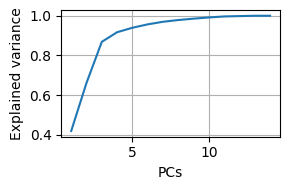

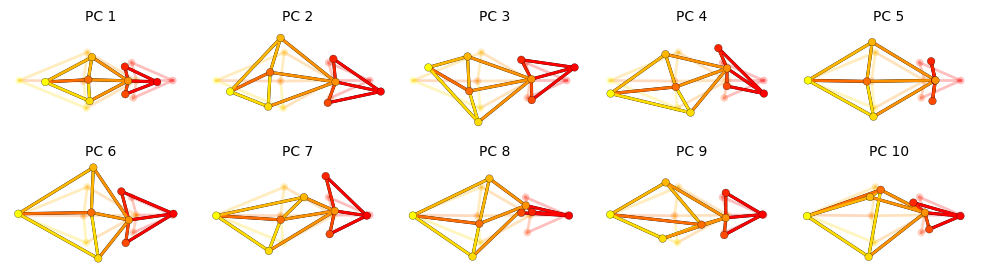

In [7]:
plt.close('all')
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config())

# use the following to load an already fit model
# pca = kpms.load_pca(project_dir)

In [8]:
kpms.update_config(project_dir, latent_dim=4)

# Model fitting

Fitting a keypoint-MoSeq model involves:
1. **Initialization:** Auto-regressive (AR) parameters and syllable sequences are randomly initialized using pose trajectories from PCA.
2. **Fitting an AR-HMM:** The AR parameters, transition probabilities and syllable sequences are iteratively updated through Gibbs sampling. 
3. **Fitting the full model:** All parameters, including both the AR-HMM as well as centroid, heading, noise-estimates and continuous latent states (i.e. pose trajectories) are iteratively updated through Gibbs sampling. This step is especially useful for noisy data.
4. **Extracting model results:** The learned states of the model are parsed and saved to disk for vizualization and downstream analysis.
4. **[Optional] Applying the trained model:** The learned model parameters can be used to infer a syllable sequences for additional data.

## Setting kappa

Most users will need to adjust the **kappa** hyperparameter to achieve the desired distribution of syllable durations. For this tutorial we chose kappa values that yielded a median syllable duration of 400ms (12 frames). Most users will need to tune kappa to their particular dataset. Higher values of kappa lead to longer syllables. **You will need to pick two kappas: one for AR-HMM fitting and one for the full model.**
- We recommend iteratively updating kappa and refitting the model until the target syllable time-scale is attained.  
- Model fitting can be stopped at any time by interrupting the kernel, and then restarted with a new kappa value.
- The full model will generally require a lower value of kappa to yield the same target syllable durations. 
- To adjust the value of kappa in the model, use `kpms.update_hypparams` as shown below. Note that this command only changes kappa in the model dictionary, not the kappa value in the config file. The value in the config is only used during model initialization.

## Initialization

In [9]:
# initialize the model
model = kpms.init_model(data, pca=pca, **config())

# optionally modify kappa
# model = kpms.update_hypparams(model, kappa=NUMBER)

## Fitting an AR-HMM

In addition to fitting an AR-HMM, the function below:
- generates a name for the model and a corresponding directory in `project_dir`
- saves a checkpoint every 25 iterations from which fitting can be restarted
- plots the progress of fitting every 25 iterations, including
    - the distributions of syllable frequencies and durations for the most recent iteration
    - the change in median syllable duration across fitting iterations
    - a sample of the syllable sequence across iterations in a random window
 
**Note:** Some users have reported systematic differences in the way syllables are assigned when applying a model to new data. To control for this, we recommend running `apply_model` to both the new and original data and using these new results instead of the original model output. To save the original results, simply rename the original `results.h5` file or save the new results to a different filename using `results_path="new_file_name.h5"`.

Outputs will be saved to C:\Users\Padilla-
Coreano\Documents\tanish\test2\2025_07_22-14_12_17


 49%|█████████████████▏                 | 25/51 [00:34<00:35,  1.36s/it]

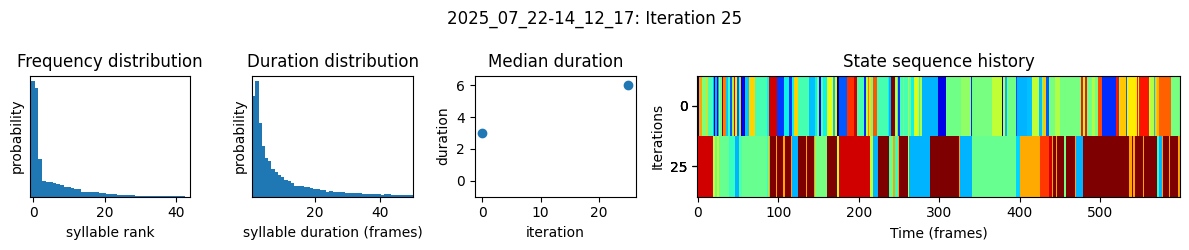

 98%|██████████████████████████████████▎| 50/51 [01:08<00:01,  1.35s/it]

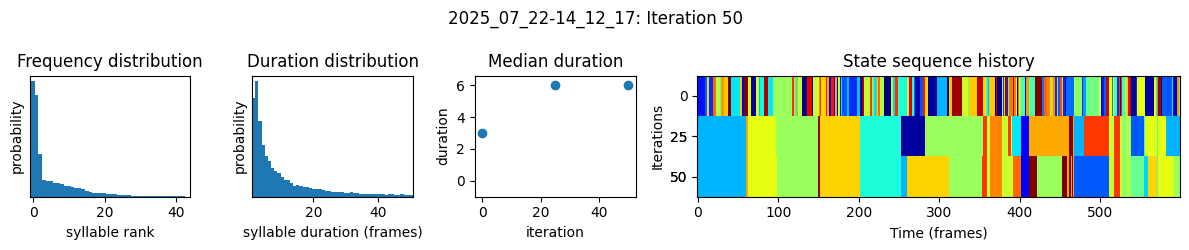

100%|███████████████████████████████████| 51/51 [01:10<00:00,  1.39s/it]


In [10]:
num_ar_iters = 50

model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, ar_only=True, num_iters=num_ar_iters
)

## Fitting the full model

The following code fits a full keypoint-MoSeq model using the results of AR-HMM fitting for initialization. If using your own data, you may need to try a few values of kappa at this step. 

In [11]:
# # load model checkpoint
# model, data, metadata, current_iter = kpms.load_checkpoint(
#     project_dir, model_name, iteration=num_ar_iters
# )

# # modify kappa to maintain the desired syllable time-scale
# model = kpms.update_hypparams(model, kappa=5000)

# # run fitting for an additional 500 iters
# model = kpms.fit_model(
#     model,
#     data,
#     metadata,
#     project_dir,
#     model_name,
#     ar_only=False,
#     start_iter=current_iter,
#     num_iters=current_iter + 500,
# )[0]

## Sort syllables by frequency

Permute the states and parameters of a saved checkpoint so that syllables are labeled in order of frequency (i.e. so that `0` is the most frequent, `1` is the second most, and so on). 

In [12]:
# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(project_dir, model_name);

Reindexing: 100%|█████████████| 3/3 [00:00<00:00, 21.33model snapshot/s]


```{warning}
Reindexing is only applied to the checkpoint file. Therefore, if you perform this step after extracting the modeling results or generating vizualizations, then those steps must be repeated.
```

## Extract model results

Parse the modeling results and save them to `{project_dir}/{model_name}/results.h5`. The results are stored as follows, and can be reloaded at a later time using `kpms.load_results`. Check the docs for an [in-depth explanation of the modeling results](https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#interpreting-model-outputs).
```
    results.h5
    ├──recording_name1
    │  ├──syllable      # syllable labels (z)
    │  ├──latent_state  # inferred low-dim pose state (x)
    │  ├──centroid      # inferred centroid (v)
    │  └──heading       # inferred heading (h)
    ⋮
```

In [13]:
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# extract results
results = kpms.extract_results(model, metadata, project_dir, model_name)

Saved results to C:\Users\Padilla-
Coreano\Documents\tanish\test2\2025_07_22-14_12_17\results.h5


In [14]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

def save_results_as_csv_with_all_keypoints(results, coordinates, project_dir, model_name, bodyparts):
    output_dir = os.path.join(project_dir, model_name, 'results_all_keypoints')
    os.makedirs(output_dir, exist_ok=True)

    print(f"Saving full keypoint CSVs to {output_dir}")

    for recording_name, result in tqdm(results.items()):
        if recording_name not in coordinates:
            print(f"Skipping {recording_name} (not found in coordinates)")
            continue
        
        n_frames = len(result['syllable'])
        coord_array = coordinates[recording_name][:n_frames]

        rows = []
        for frame in range(n_frames):
            row = {
                "recording": recording_name,
                "frame": frame,
                "syllable": result['syllable'][frame]
            }
            for b_idx, bodypart in enumerate(bodyparts):
                row[f"{bodypart}_x"] = coord_array[frame, b_idx, 0]
                row[f"{bodypart}_y"] = coord_array[frame, b_idx, 1]
            rows.append(row)

        df = pd.DataFrame(rows)
        out_file = os.path.join(output_dir, f"{recording_name}.csv")
        df.to_csv(out_file, index=False)

    print(f"✔ All CSVs saved under: {output_dir}")


In [15]:
save_results_as_csv_with_all_keypoints(results, coordinates, project_dir, model_name, bodyparts)



Saving full keypoint CSVs to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_12_17\results_all_keypoints


100%|██████████| 16/16 [00:04<00:00,  3.27it/s]

✔ All CSVs saved under: C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_12_17\results_all_keypoints


### [Optional] Save results to csv

After extracting to an h5 file, the results can also be saved as csv files. A separate file will be created for each recording and saved to `{project_dir}/{model_name}/results/`. 

In [16]:
# optionally save results as csv
kpms.save_results_as_csv(results, project_dir, model_name)

Saving to csv: 100%|████████████████████| 16/16 [00:00<00:00, 20.81it/s]


In [17]:
import numpy as np

all_syllables = np.concatenate([v['syllable'] for v in results.values()])
print("Total unique syllables:", len(np.unique(all_syllables)))


Total unique syllables: 97


Saving trajectory plots to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_12_17\trajectory_plots


Generating trajectory plots: 100%|██████| 23/23 [00:08<00:00,  2.64it/s]


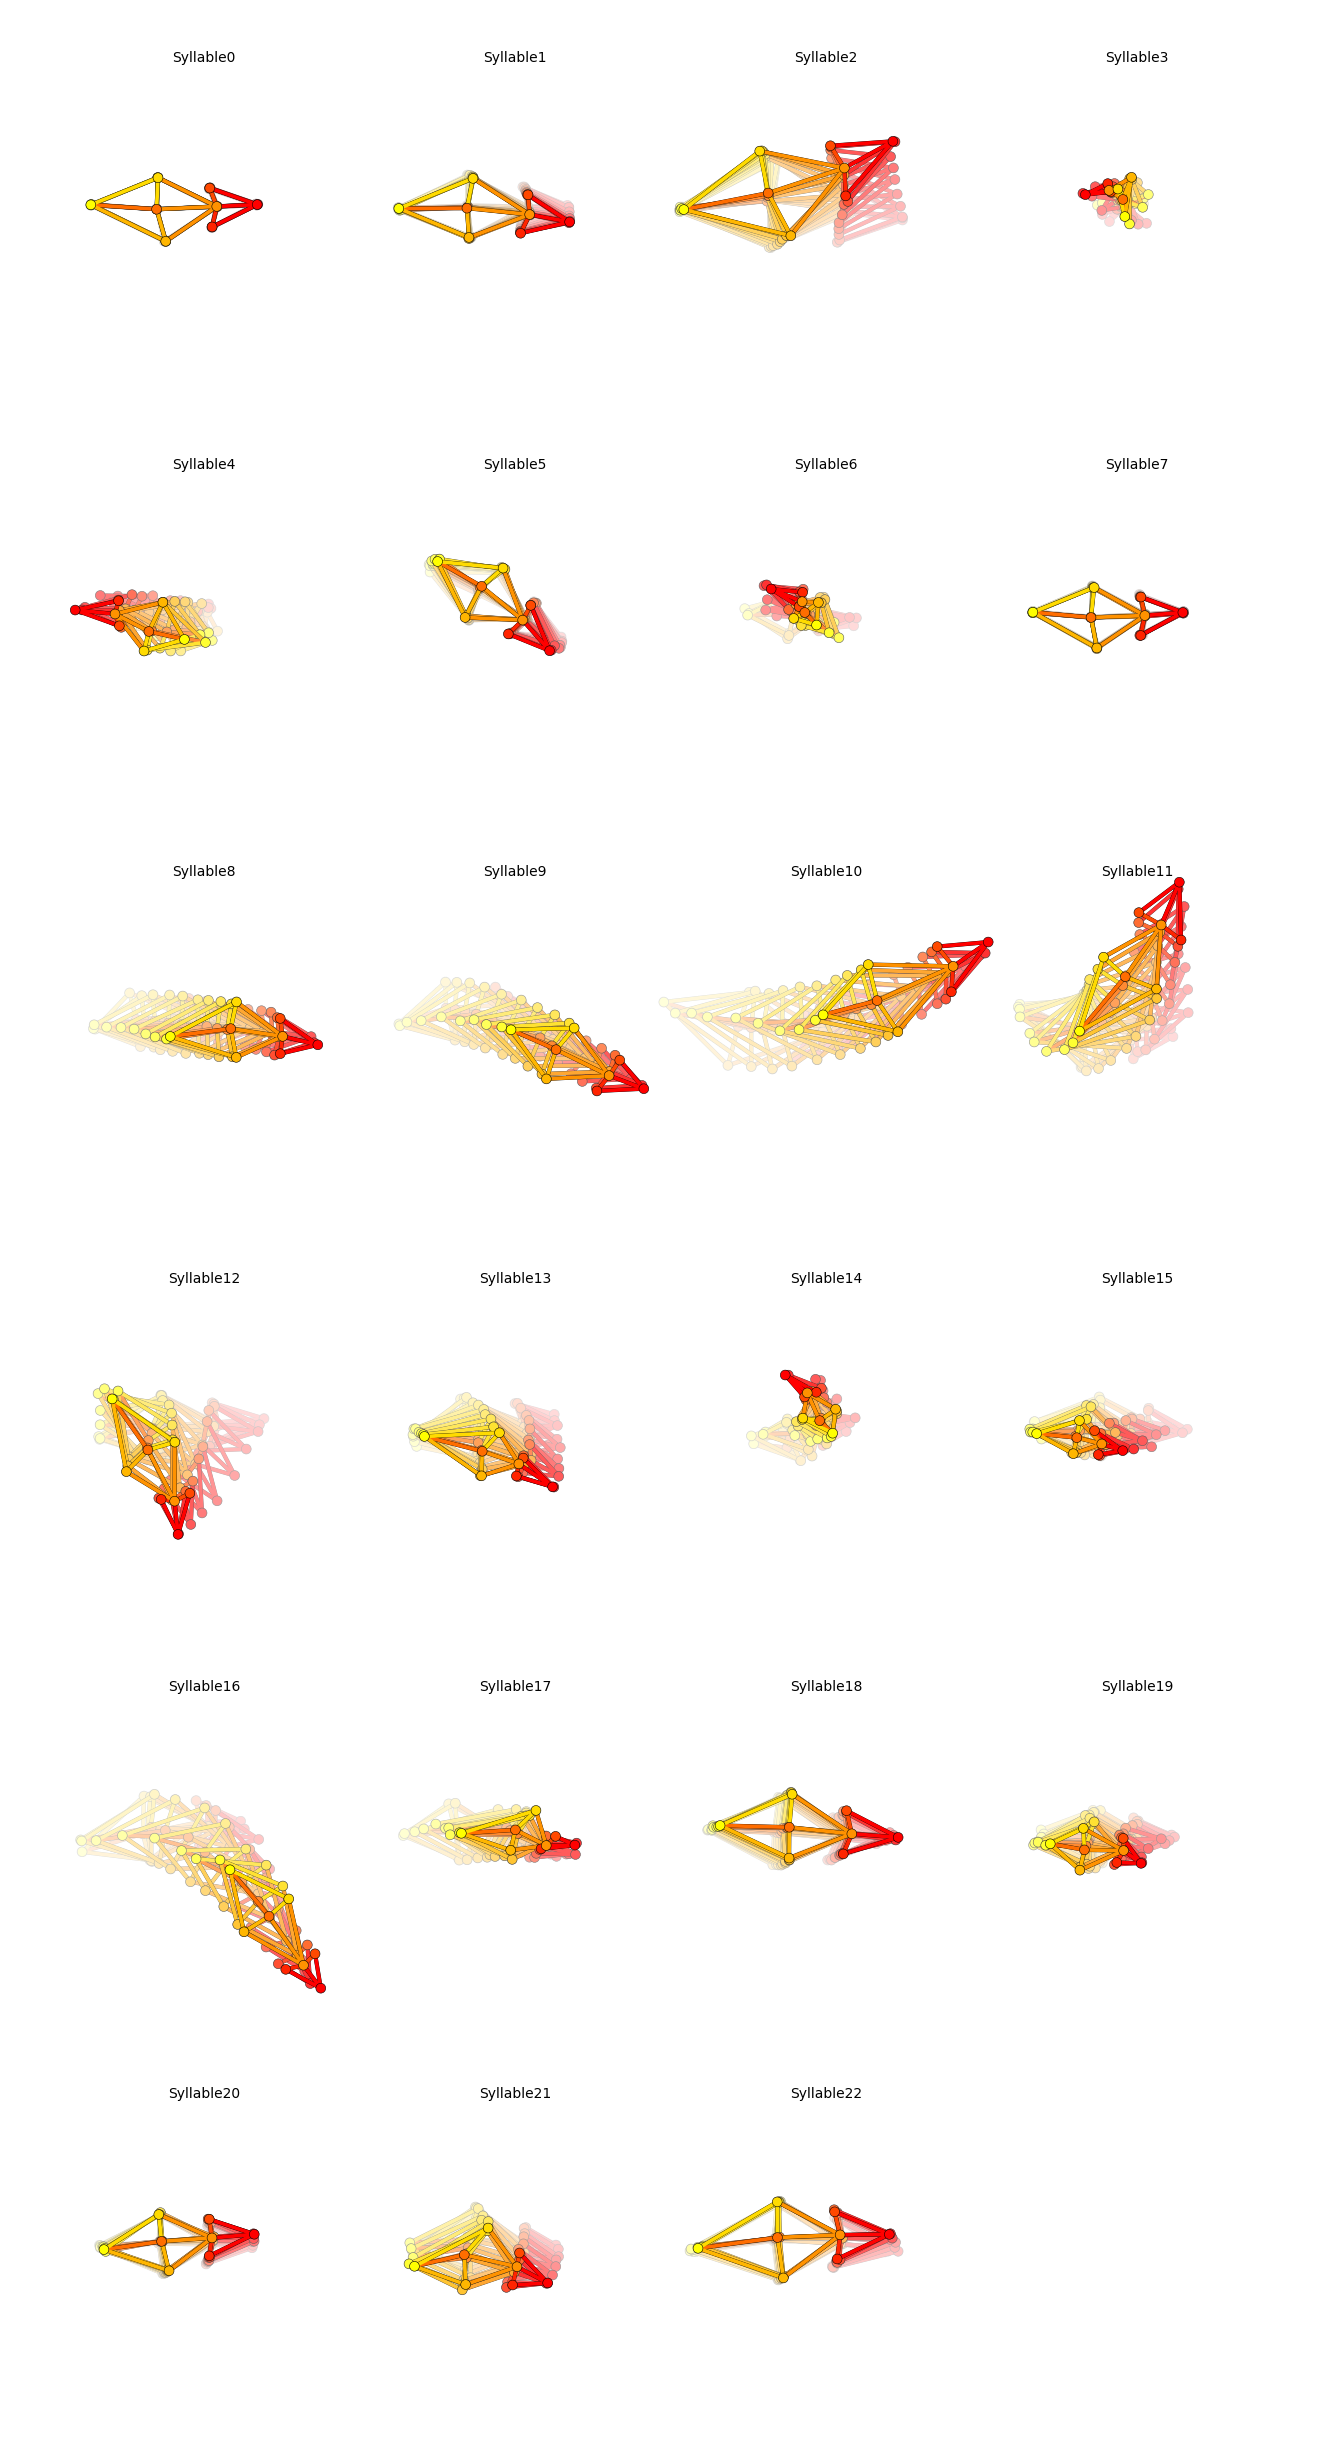

Saving dendrogram plot to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_12_17\similarity_dendrogram


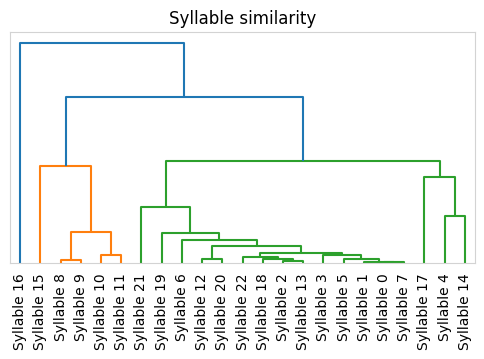

In [18]:
# Get all unique syllables
unique_syllables = sorted(np.unique(all_syllables))

# Trajectory plots
kpms.generate_trajectory_plots(
    coordinates,
    results,
    project_dir,
    model_name,
    syllables=unique_syllables,  # Force all syllables to be plotted
    **config()
)

# Dendrogram
kpms.plot_similarity_dendrogram(
    coordinates,
    results,
    project_dir,
    model_name,
    syllables=unique_syllables,  # Force all syllables to be plotted
    **config()
)


In [19]:
# Keep only syllables that occur at least 50 times
from collections import Counter

counts = Counter(all_syllables)
frequent_syllables = sorted([s for s, c in counts.items() if c >= 50])

# Then use in the plots as shown above


## Trajectory plots
Generate plots showing the median trajectory of poses associated with each given syllable. 

Saving trajectory plots to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_12_17\trajectory_plots


Generating trajectory plots: 100%|██████| 23/23 [00:08<00:00,  2.65it/s]


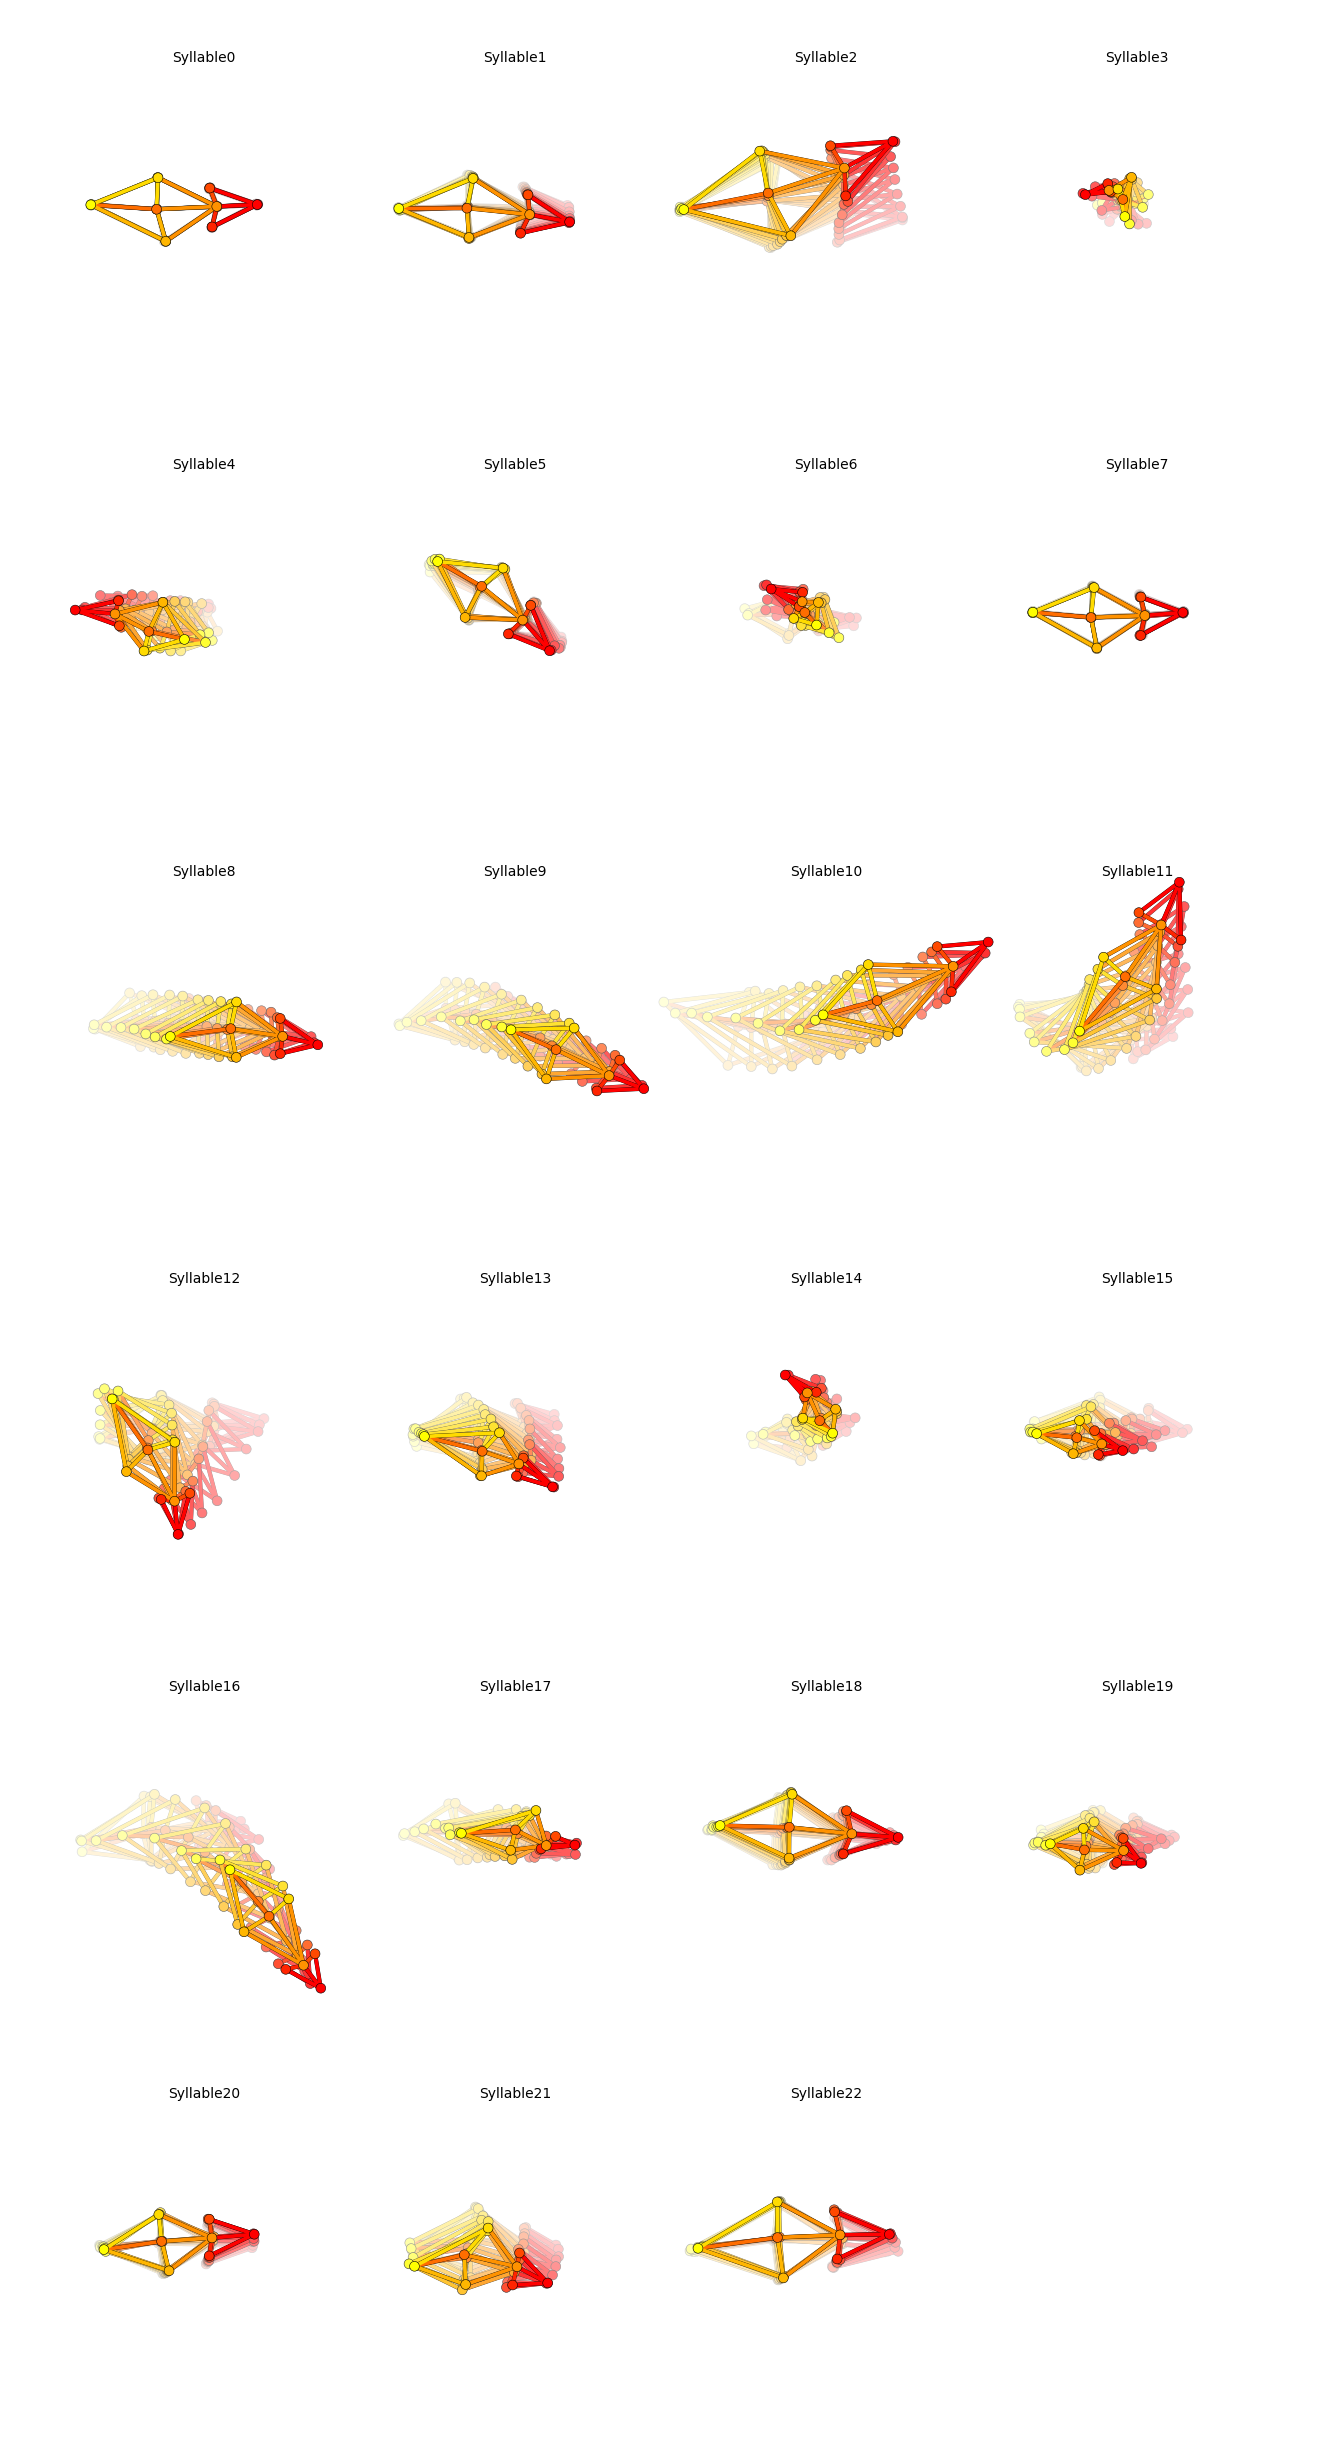

In [20]:
results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(
    coordinates,
    results,
    project_dir,
    model_name,
    max_syllables=None,  # ← uncaps the number
    **config()
)

## Grid movies
Generate video clips showing examples of each syllable. 

*Note: the code below will only work with 2D data. For 3D data, see the [FAQ](https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#making-grid-movies-for-3d-data).*

In [21]:
kpms.generate_grid_movies(results, project_dir, model_name, coordinates=coordinates, **config());

Writing grid movies to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_12_17\grid_movies


c:\ProgramData\anaconda3\envs\kpms-env\lib\site-packages\keypoint_moseq\viz.py:1324: UserWarning:


Videos will be downscaled by a factor of 0.71 so that the grid movies
are under 1920 pixels. Use `max_video_size` to increase or decrease
this size limit.





Using window size of 448 pixels


Generating grid movies: 100%|███████████| 23/23 [03:29<00:00,  9.11s/it]


In [22]:
video_dir = config()["video_dir"]
print(kpms.find_matching_videos(results.keys(), video_dir))

['C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s1_2_p5_1_nRB6_20250622_170742.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s1_2_p5_1_nRB6_20250622_170742.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s2_3_p5_3_nRB3_20250622_104059.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s2_3_p5_3_nRB3_20250622_104059.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s2_4_p5_4_nRB3_20250622_123424.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s2_4_p5_4_nRB3_20250622_123424.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\kpms_test\\top-RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4', 'C:\\Users\\Padilla-C

## Syllable Dendrogram
Plot a dendrogram representing distances between each syllable's median trajectory.

Saving dendrogram plot to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_12_17\similarity_dendrogram


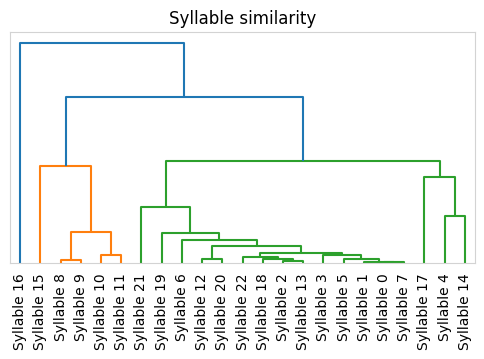

In [23]:
kpms.plot_similarity_dendrogram(
    coordinates,
    results,
    project_dir,
    model_name,
    max_syllables=None,  # ← removes cap
    **config()
)

In [24]:
kpms.update_config(
    project_dir,
    # video_dir=r"C:\Users\Padilla-Coreano\Downloads\RI1_s2_3_p5_3_nRB3_20250622_104059.1.mp4",
    video_dir = r"C:\Users\Padilla-Coreano\Desktop\Kpms_RI2",
    anterior_bodyparts=["nose"],
    posterior_bodyparts=["tail_base"],
    use_bodyparts=["nose", "right_ear", "left_ear", "middle", "head", "right_mid", "left_mid", "tail_base"],
    fps=30
)

In [25]:
# load data (e.g. from DeepLabCut)
keypoint_data_path = sleap_file  # can be a file, a directory, or a list of files
keypoint_data_path = r"C:\Users\Padilla-Coreano\Desktop\Kpms_RI2"  # can be a file, a directory, or a list of files

coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "sleap")

# format data for modeling
data, metadata = kpms.format_data(coordinates, confidences, **config())

Loading keypoints: 100%|██████████████████| 9/9 [00:00<00:00, 60.08it/s]


In [26]:
from vidio.read import OpenCVReader
videos = kpms.find_matching_videos(confidences.keys(), config()['video_dir'], as_dict=True)

if not len(videos) == len(confidences):
    raise RuntimeError(f'{len(videos)} videos found for {len(confidences)} keys in confidences')

for key, video in videos.items():
    reader = OpenCVReader(video)
    if not len(confidences[key]) == reader.nframes:
        print(f'{video} has {reader.nframes} frames but {key} has {len(confidences[key])} entries')
    reader.close()

C:\Users\Padilla-Coreano\Desktop\Kpms_RI2\top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.mp4 has 18235 frames but top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.analysis_track0 has 18153 entries
C:\Users\Padilla-Coreano\Desktop\Kpms_RI2\top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.mp4 has 18235 frames but top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.analysis_track1 has 18153 entries


>=90.0% of variance exlained by 5 components.


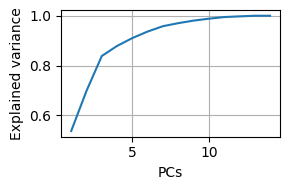

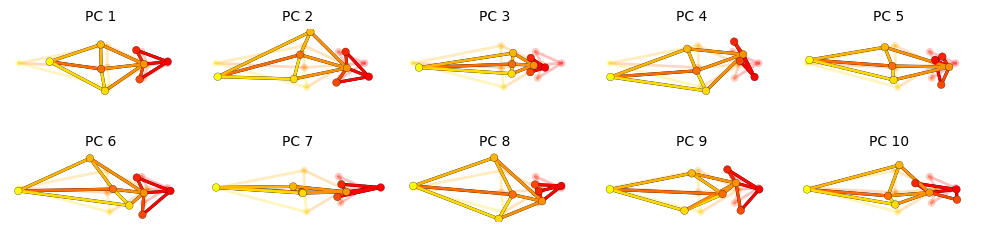

In [27]:
plt.close('all')
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config())

# use the following to load an already fit model
# pca = kpms.load_pca(project_dir)

In [28]:
# initialize the model
model = kpms.init_model(data, pca=pca, **config())

# optionally modify kappa
# model = kpms.update_hypparams(model, kappa=NUMBER)

Outputs will be saved to C:\Users\Padilla-
Coreano\Documents\tanish\test2\2025_07_22-14_17_52


 49%|█████████████████▏                 | 25/51 [00:40<00:41,  1.59s/it]

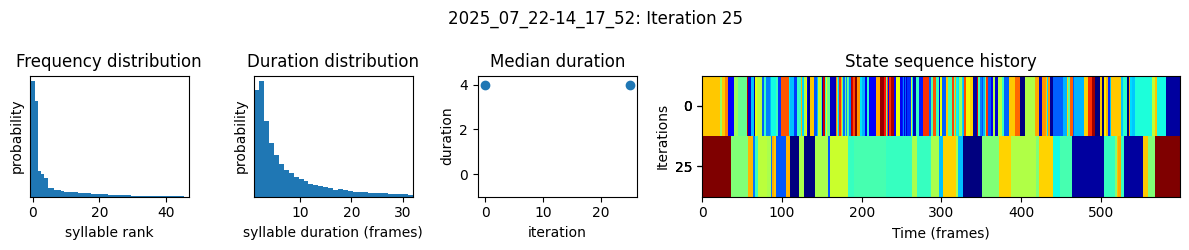

 98%|██████████████████████████████████▎| 50/51 [01:20<00:01,  1.58s/it]

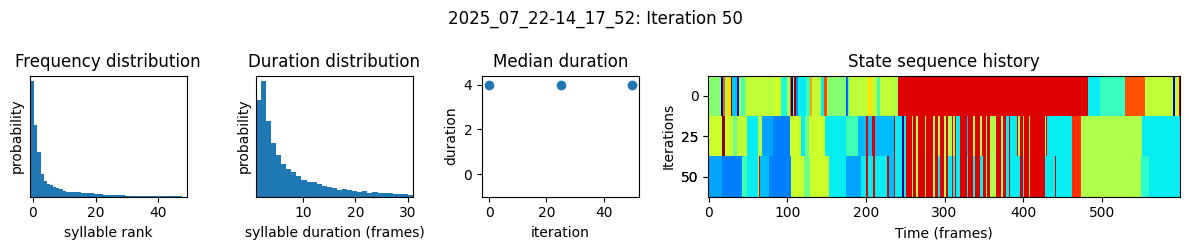

100%|███████████████████████████████████| 51/51 [01:22<00:00,  1.61s/it]


In [29]:
num_ar_iters = 50

model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, ar_only=True, num_iters=num_ar_iters
)

In [30]:
# # load model checkpoint
# model, data, metadata, current_iter = kpms.load_checkpoint(
#     project_dir, model_name, iteration=num_ar_iters
# )

# # modify kappa to maintain the desired syllable time-scale
# model = kpms.update_hypparams(model, kappa=5000)

# # run fitting for an additional 500 iters
# model = kpms.fit_model(
#     model,
#     data,
#     metadata,
#     project_dir,
#     model_name,
#     ar_only=False,
#     start_iter=current_iter,
#     num_iters=current_iter + 500,
# )[0]

In [31]:
# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(project_dir, model_name);

Reindexing: 100%|█████████████| 3/3 [00:00<00:00, 20.08model snapshot/s]


In [32]:
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# extract results
results = kpms.extract_results(model, metadata, project_dir, model_name)

Saved results to C:\Users\Padilla-
Coreano\Documents\tanish\test2\2025_07_22-14_17_52\results.h5


In [33]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

def save_results_as_csv_with_all_keypoints(results, coordinates, project_dir, model_name, bodyparts):
    output_dir = os.path.join(project_dir, model_name, 'results_all_keypoints')
    os.makedirs(output_dir, exist_ok=True)

    print(f"Saving full keypoint CSVs to {output_dir}")

    for recording_name, result in tqdm(results.items()):
        if recording_name not in coordinates:
            print(f"Skipping {recording_name} (not found in coordinates)")
            continue
        
        n_frames = len(result['syllable'])
        coord_array = coordinates[recording_name][:n_frames]

        rows = []
        for frame in range(n_frames):
            row = {
                "recording": recording_name,
                "frame": frame,
                "syllable": result['syllable'][frame]
            }
            for b_idx, bodypart in enumerate(bodyparts):
                row[f"{bodypart}_x"] = coord_array[frame, b_idx, 0]
                row[f"{bodypart}_y"] = coord_array[frame, b_idx, 1]
            rows.append(row)

        df = pd.DataFrame(rows)
        out_file = os.path.join(output_dir, f"{recording_name}.csv")
        df.to_csv(out_file, index=False)

    print(f"✔ All CSVs saved under: {output_dir}")


In [34]:
save_results_as_csv_with_all_keypoints(results, coordinates, project_dir, model_name, bodyparts)



Saving full keypoint CSVs to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_17_52\results_all_keypoints


100%|██████████| 18/18 [00:05<00:00,  3.33it/s]

✔ All CSVs saved under: C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_17_52\results_all_keypoints


In [35]:
# optionally save results as csv
kpms.save_results_as_csv(results, project_dir, model_name)

Saving to csv: 100%|████████████████████| 18/18 [00:00<00:00, 21.55it/s]


In [36]:
import numpy as np

all_syllables = np.concatenate([v['syllable'] for v in results.values()])
print("Total unique syllables:", len(np.unique(all_syllables)))


Total unique syllables: 95


Saving trajectory plots to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_17_52\trajectory_plots


Generating trajectory plots: 100%|██████| 24/24 [00:09<00:00,  2.58it/s]


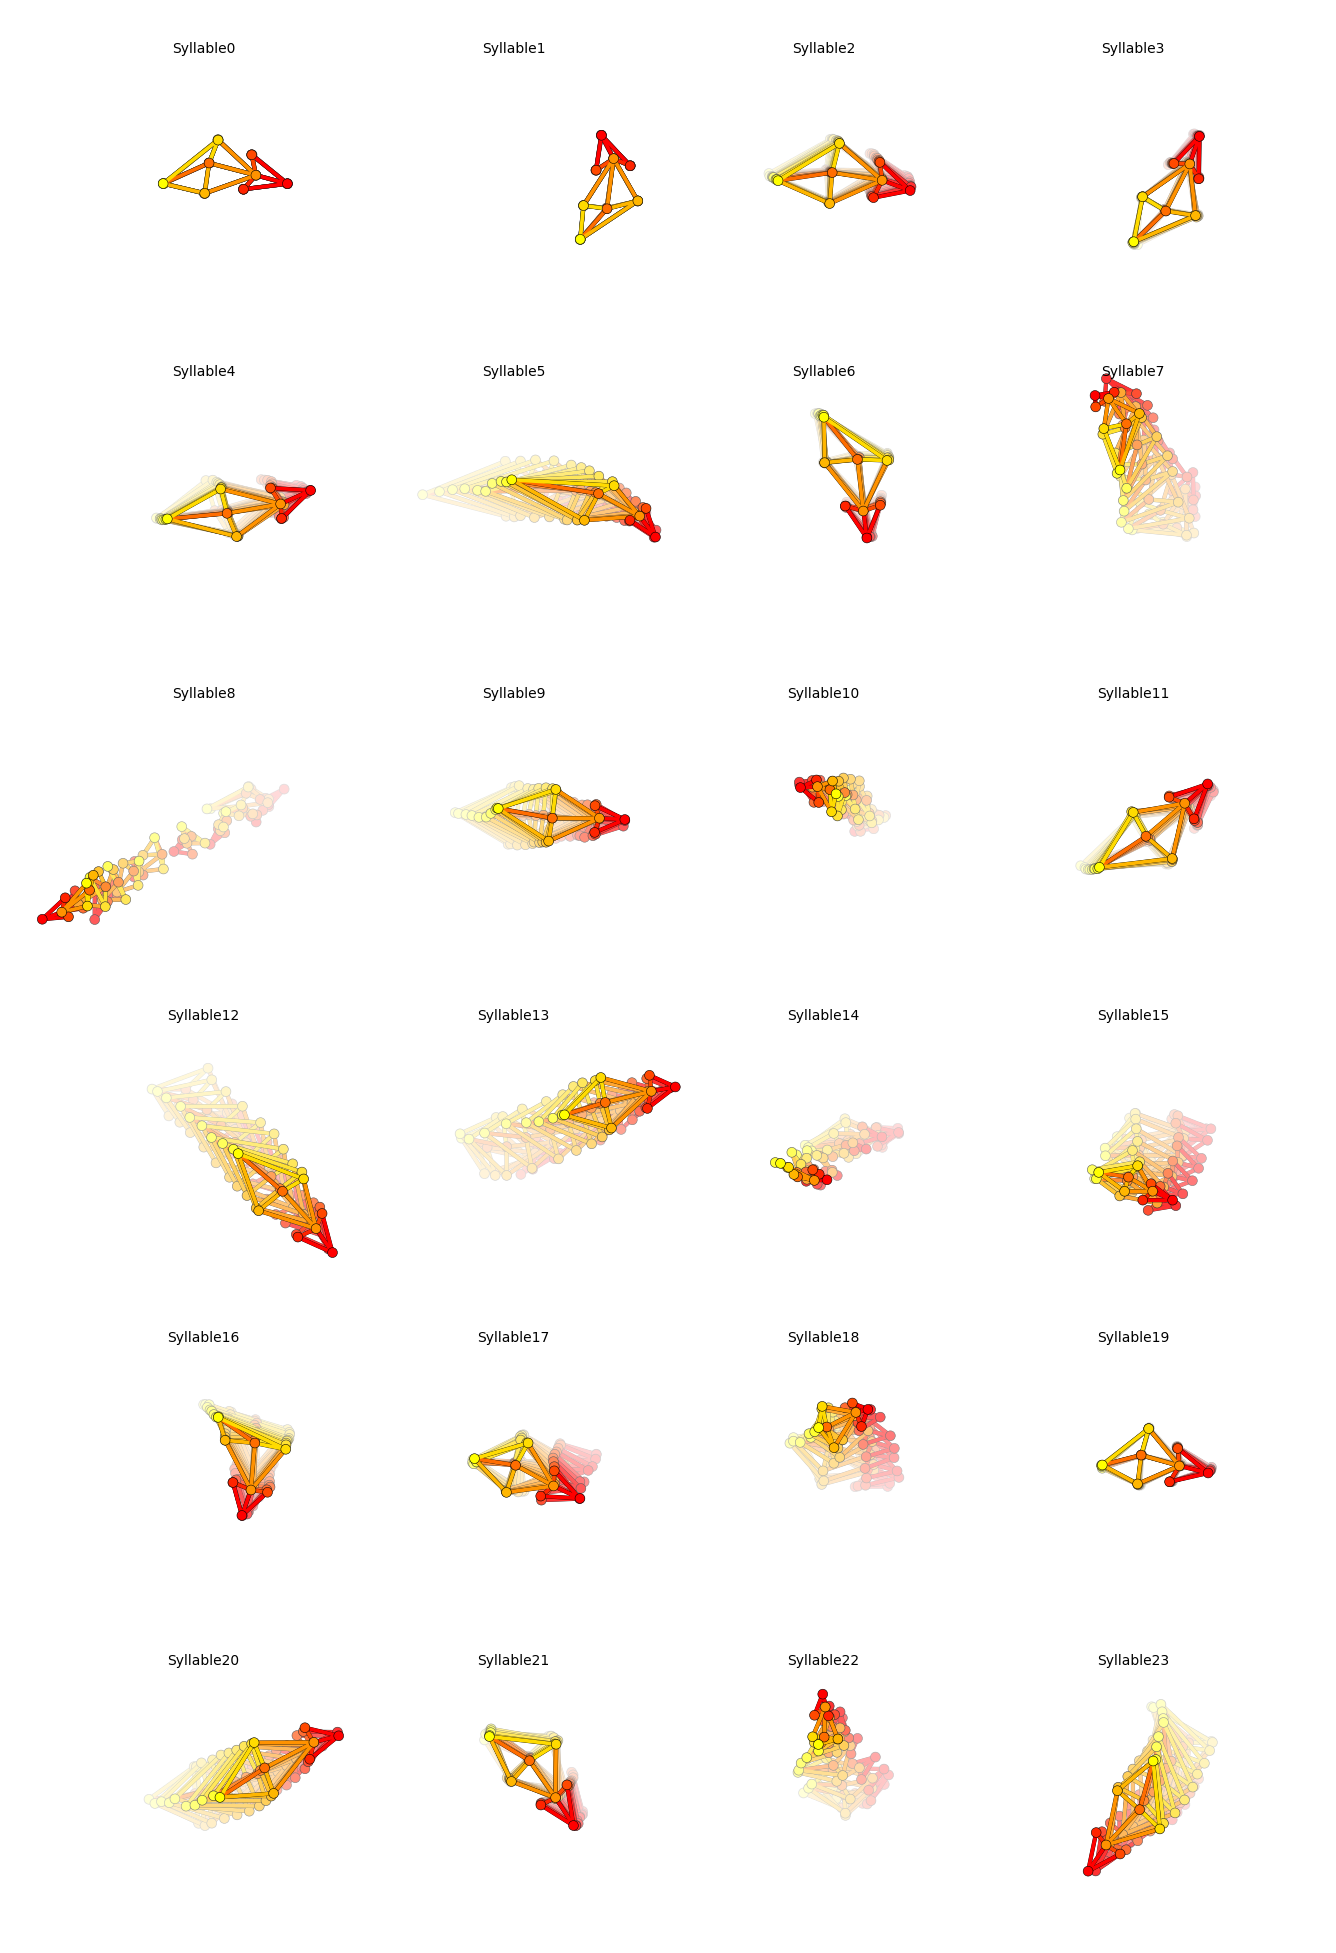

Saving dendrogram plot to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_17_52\similarity_dendrogram


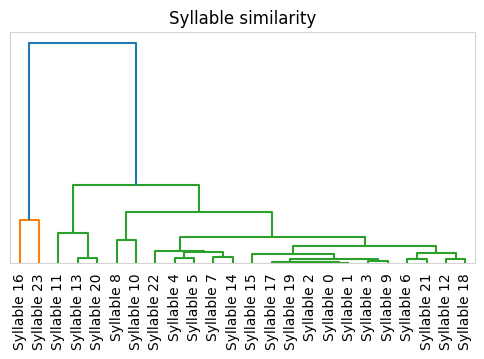

In [37]:
# Get all unique syllables
unique_syllables = sorted(np.unique(all_syllables))

# Trajectory plots
kpms.generate_trajectory_plots(
    coordinates,
    results,
    project_dir,
    model_name,
    syllables=unique_syllables,  # Force all syllables to be plotted
    **config()
)

# Dendrogram
kpms.plot_similarity_dendrogram(
    coordinates,
    results,
    project_dir,
    model_name,
    syllables=unique_syllables,  # Force all syllables to be plotted
    **config()
)


In [38]:
# Keep only syllables that occur at least 50 times
from collections import Counter

counts = Counter(all_syllables)
frequent_syllables = sorted([s for s, c in counts.items() if c >= 50])

# Then use in the plots as shown above


In [39]:
from keypoint_moseq import generate_trajectory_plots, plot_similarity_dendrogram, plot_syllable_frequencies
import numpy as np
from collections import Counter

# Step 1: Load all syllables from your results
all_syllables = np.concatenate([v['syllable'] for v in results.values()])
unique_syllables = sorted(np.unique(all_syllables))

print(f"Found {len(unique_syllables)} unique syllables: {unique_syllables}")

# Step 2: Check syllable frequencies
syllable_counts = Counter(all_syllables)
print(f"\nSyllable frequencies:")
for syll in sorted(syllable_counts.keys()):
    print(f"  Syllable {syll}: {syllable_counts[syll]} occurrences")

# Step 3: Generate trajectory plots for ALL syllables with minimal filtering
print(f"\n{'='*50}")
print("GENERATING TRAJECTORY PLOTS FOR ALL SYLLABLES")
print(f"{'='*50}")

try:
    generate_trajectory_plots(
        coordinates,
        results,
        project_dir,
        model_name,
        syllables=unique_syllables,  # ALL syllables
        fps=30,
        pre=0.1,  # Very short pre-window
        post=0.1,  # Very short post-window
        min_frequency=1,  # Minimum possible - include syllables that occur just once
        min_duration=0.001,  # Extremely short minimum duration (1ms)
        save_individually=True,
        save_gifs=True,
        save_mp4s=False,
        interactive=False,
        # Additional parameters to force inclusion
        get_limits_pctl=(1, 99),  # Use wider percentile range for limits
        padding=1.1  # Add some padding
    )
    print(f"✓ Trajectory plots generated for all {len(unique_syllables)} syllables!")
except Exception as e:
    print(f"Error with all syllables: {e}")
    
    # Try generating plots in smaller batches
    print("\nTrying to generate plots in batches...")
    batch_size = 10
    successful_batches = 0
    
    for i in range(0, len(unique_syllables), batch_size):
        batch = unique_syllables[i:i+batch_size]
        batch_num = i // batch_size + 1
        print(f"\nProcessing batch {batch_num}: syllables {batch}")
        
        try:
            generate_trajectory_plots(
                coordinates,
                results,
                project_dir,
                model_name,
                syllables=batch,
                fps=30,
                pre=0.05,  # Even shorter
                post=0.05,
                min_frequency=1,
                min_duration=0.001,
                save_individually=True,
                save_gifs=True,
                save_mp4s=False,
                interactive=False,
                output_dir=f"{project_dir}/{model_name}/trajectory_plots_batch_{batch_num}"
            )
            successful_batches += 1
            print(f"  ✓ Batch {batch_num} completed successfully")
        except Exception as batch_error:
            print(f"  ✗ Batch {batch_num} failed: {batch_error}")
            
            # Try individual syllables in this batch
            print(f"    Trying individual syllables from batch {batch_num}...")
            for syll in batch:
                try:
                    generate_trajectory_plots(
                        coordinates,
                        results,
                        project_dir,
                        model_name,
                        syllables=[syll],  # Single syllable
                        fps=30,
                        pre=0.03,
                        post=0.03,
                        min_frequency=1,
                        min_duration=0.001,
                        save_individually=True,
                        save_gifs=True,
                        save_mp4s=False,
                        interactive=False,
                        output_dir=f"{project_dir}/{model_name}/trajectory_plots_individual"
                    )
                    print(f"      ✓ Syllable {syll} completed")
                except Exception as syll_error:
                    print(f"      ✗ Syllable {syll} failed: {syll_error}")
    
    print(f"\nBatch processing complete: {successful_batches} batches successful")

# Step 4: Check what files were actually generated
import os
output_dir = f"{project_dir}/{model_name}"
if os.path.exists(output_dir):
    print(f"\n{'='*50}")
    print("CHECKING GENERATED FILES")
    print(f"{'='*50}")
    
    # Look for trajectory plot files
    trajectory_files = []
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            if 'trajectory' in file.lower() and (file.endswith('.gif') or file.endswith('.png') or file.endswith('.mp4')):
                trajectory_files.append(os.path.join(root, file))
    
    print(f"Found {len(trajectory_files)} trajectory plot files:")
    for file in sorted(trajectory_files)[:10]:  # Show first 10
        print(f"  {os.path.basename(file)}")
    
    if len(trajectory_files) > 10:
        print(f"  ... and {len(trajectory_files) - 10} more files")
    
    # Extract syllable numbers from filenames to see which ones were generated
    generated_syllables = set()
    for file in trajectory_files:
        filename = os.path.basename(file)
        # Try to extract syllable number from filename
        import re
        matches = re.findall(r'syllable[_\s]*(\d+)', filename, re.IGNORECASE)
        if matches:
            generated_syllables.update([int(m) for m in matches])
    
    print(f"\nGenerated plots for {len(generated_syllables)} syllables: {sorted(generated_syllables)}")
    missing_syllables = set(unique_syllables) - generated_syllables
    if missing_syllables:
        print(f"Missing plots for {len(missing_syllables)} syllables: {sorted(missing_syllables)}")

print("\n" + "="*50)
print("TRAJECTORY GENERATION COMPLETE")
print("="*50)

Found 95 unique syllables: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]

Syllable frequencies:
  Syllable 0: 39297 occurrences
  Syllable 1: 26781 occurrences
  Syllable 2: 35095 occurrences
  Syllable 3: 11210 occurrences
  Syllable 4: 15319 occurrences
  Syllable 5: 13770 occurrences
  Syllable 6: 12341 occurrences
  Syllable 7: 8151 occurrences
  Syllable 8: 3473 occurrences
  Syllable 9: 10180 occurrences
  Syllable 10: 2475 occurrences
  Syllable 11: 9421 occurrences
  Syllable 12: 10769 occurrences
  Syllable 13: 7406 occurrences
  Syllable 14: 2753 occurrences
  Syllable 15: 4408 occurrences
  Syllable 16: 7182 occurrences
  Syllable 17: 4953 occurrences
  Sy

Saving trajectory plots to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_17_52\trajectory_plots


Generating trajectory plots: 100%|██████| 24/24 [00:08<00:00,  2.89it/s]


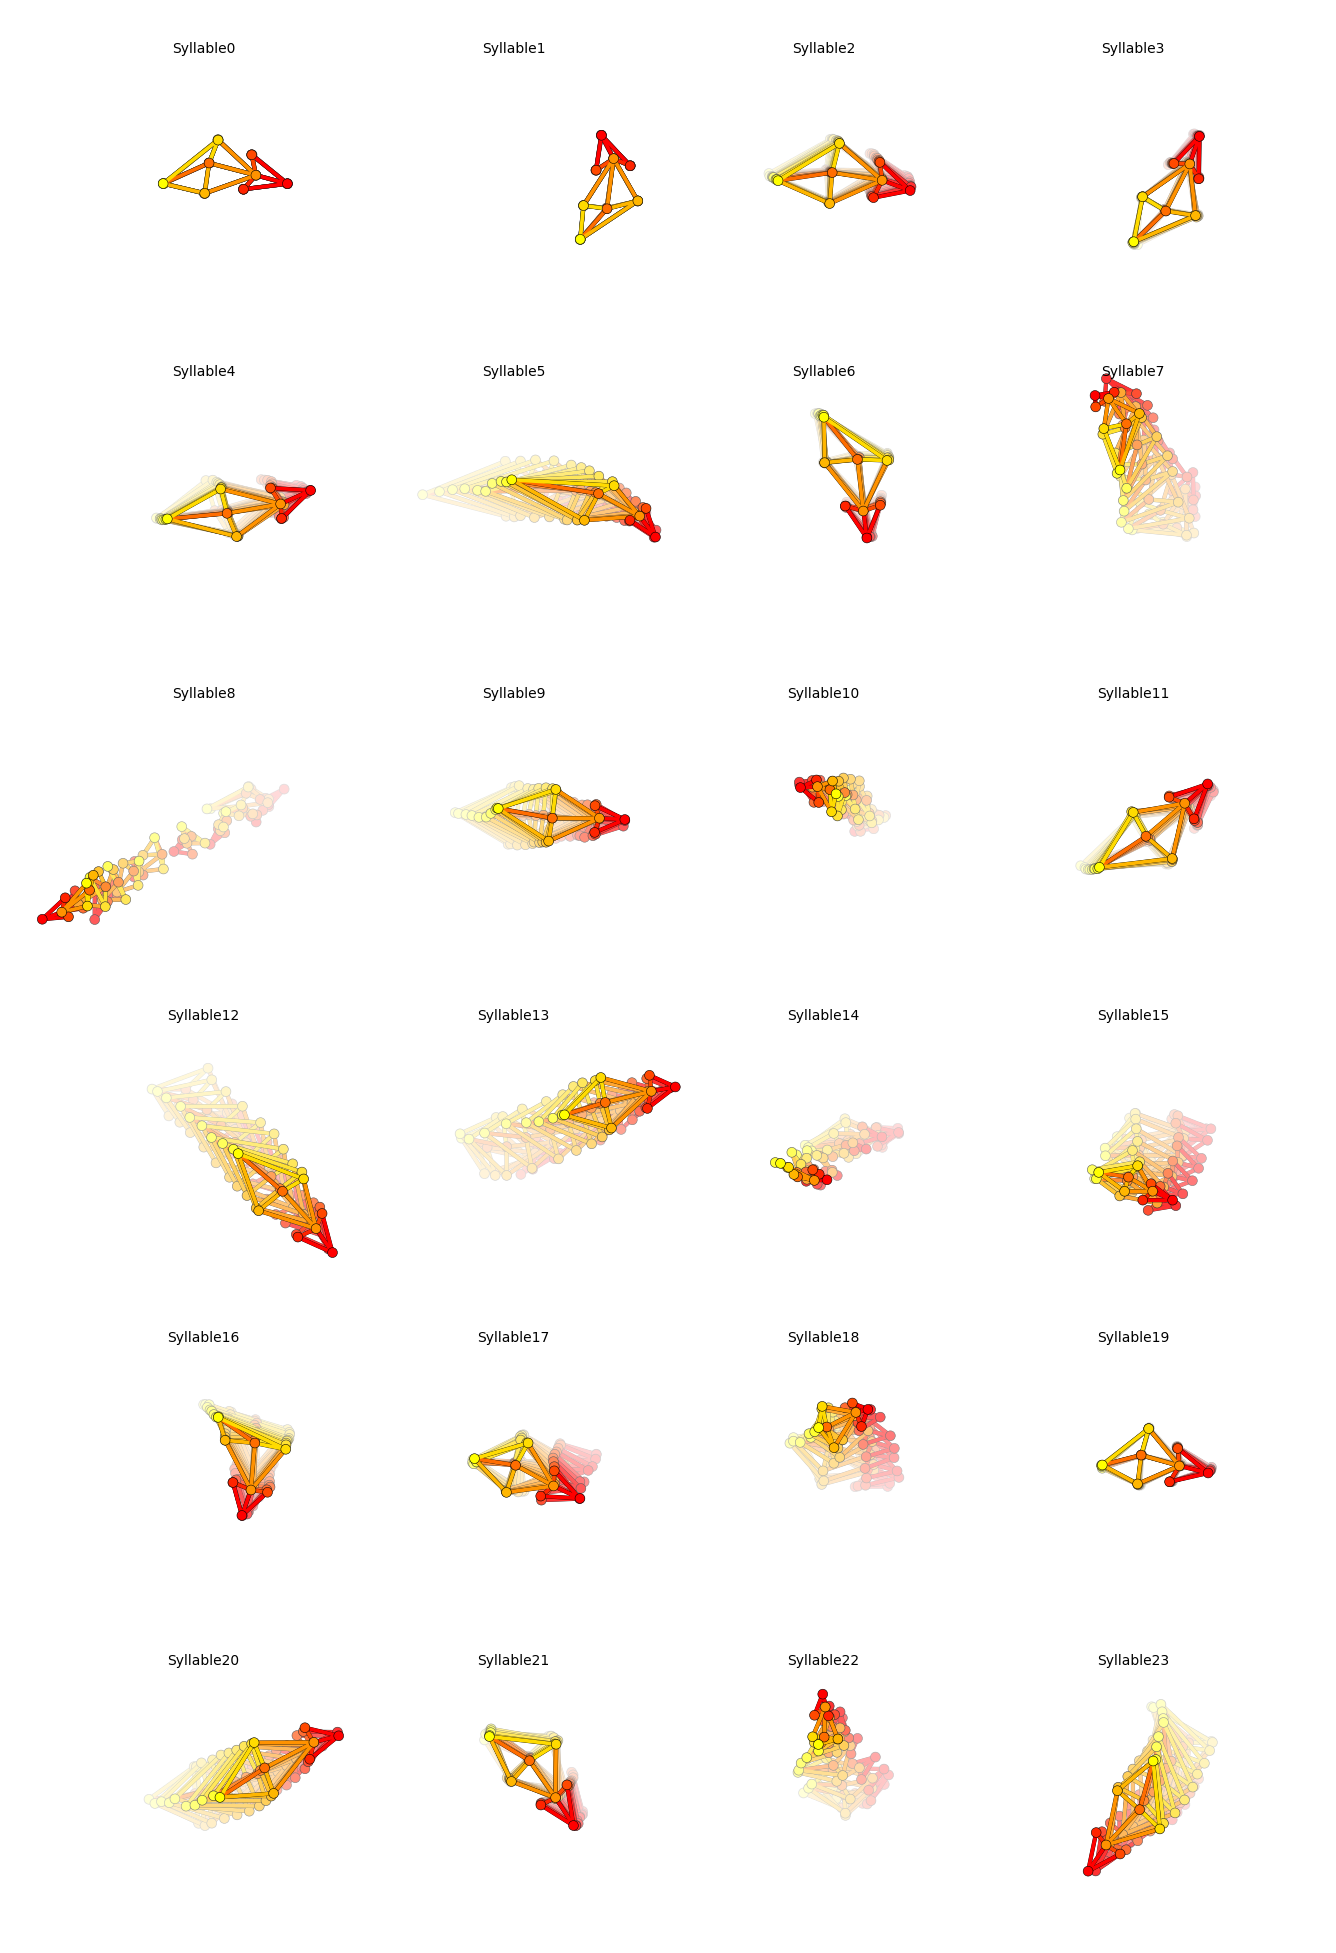

In [40]:
results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(
    coordinates,
    results,
    project_dir,
    model_name,
    max_syllables=None,  # ← uncaps the number
    **config()
)

In [41]:
kpms.generate_grid_movies(results, project_dir, model_name, coordinates=coordinates, **config());

Writing grid movies to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_17_52\grid_movies


c:\ProgramData\anaconda3\envs\kpms-env\lib\site-packages\keypoint_moseq\viz.py:1324: UserWarning:


Videos will be downscaled by a factor of 0.67 so that the grid movies
are under 1920 pixels. Use `max_video_size` to increase or decrease
this size limit.





Using window size of 480 pixels


Generating grid movies: 100%|███████████| 24/24 [02:53<00:00,  7.25s/it]


In [42]:
video_dir = config()["video_dir"]
print(kpms.find_matching_videos(results.keys(), video_dir))

['C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s1_1_p5_2_nRB6_20250622_150457.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s1_1_p5_2_nRB6_20250622_150457.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s1_2_p5_1_nRB6_20250622_173049.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s1_2_p5_1_nRB6_20250622_173049.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s2_4_p5_4_nRB3_20250622_125648.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s2_4_p5_4_nRB3_20250622_125648.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s3_5_p5_4_nRB3_20250621_112618.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\top-RI2_s3_5_p5_4_nRB3_20250621_112618.1.mp4', 'C:\\Users\\Padilla-Coreano\\Desktop\\Kpms_RI2\\t

Saving dendrogram plot to C:\Users\Padilla-Coreano\Documents\tanish\test2\2025_07_22-14_17_52\similarity_dendrogram


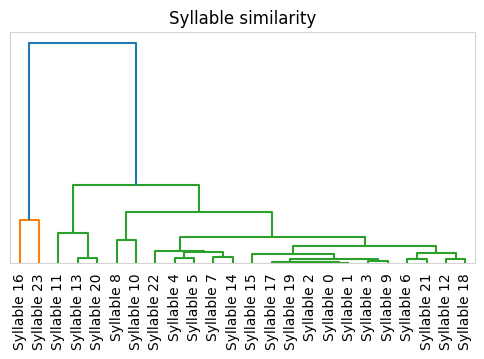

In [43]:
kpms.plot_similarity_dendrogram(
    coordinates,
    results,
    project_dir,
    model_name,
    max_syllables=None,  # ← removes cap
    **config()
)

In [ ]:
import os
import numpy as np
import pandas as pd
from collections import Counter
from keypoint_moseq.io import load_results
import keypoint_moseq as kpms
import sys

# -----------------------------------
# CONFIGURATION FOR RI1 DATA
# -----------------------------------
project_dir = r"C:\Users\Padilla-Coreano\Documents\tanish\test2"
model_name = "RI1 Upd"  # Updated RI1 model path
keypoint_data_path = r"C:\Users\Padilla-Coreano\Desktop\kpms_test"

print(f"=== RI1 SYLLABLE ENRICHMENT ANALYSIS: CLOSE vs FAR ===")
print(f"Project directory: {project_dir}")
print(f"Model name: {model_name}")
print(f"Keypoint data path: {keypoint_data_path}")
print("-" * 60)

# -----------------------------------
# LOAD RESULTS AND COORDINATES
# -----------------------------------
try:
    print("Loading RI1 results...")
    results = load_results(project_dir, model_name)
    print(f"✓ Results loaded successfully")
except Exception as e:
    print(f"✗ Error loading results: {e}")
    sys.exit(1)

try:
    print("Loading keypoint coordinates...")
    coordinates, _, _ = kpms.load_keypoints(keypoint_data_path, "sleap")
    print(f"✓ Coordinates loaded successfully")
except Exception as e:
    print(f"✗ Error loading coordinates: {e}")
    sys.exit(1)

# List all tracks in results
track_names = list(results.keys())
print(f"\nTracks found in results ({len(track_names)}): {track_names[:3]}..." if len(track_names) > 3 else f"Tracks found in results ({len(track_names)}): {track_names}")

# Group track names into pairs from the same video
video_to_tracks = {}
for name in track_names:
    if '_track' in name:
        video_id = name.rsplit('_track', 1)[0]
        video_to_tracks.setdefault(video_id, []).append(name)

print(f"Video pairs found: {len(video_to_tracks)}")

# -----------------------------------
# FUNCTION TO COMPUTE DISTANCES
# -----------------------------------
def compute_min_intermouse_distance(coords0, coords1):
    """Compute minimum distance between any bodypart of mouse 0 and any bodypart of mouse 1 for each frame."""
    n_frames = coords0.shape[0]
    n_bodyparts0 = coords0.shape[1]
    n_bodyparts1 = coords1.shape[1]
    
    min_dists = np.full(n_frames, np.inf)
    
    for frame in range(n_frames):
        frame_min_dist = np.inf
        for bp0 in range(n_bodyparts0):
            for bp1 in range(n_bodyparts1):
                coord0 = coords0[frame, bp0, :]
                coord1 = coords1[frame, bp1, :]
                
                if np.any(np.isnan(coord0)) or np.any(np.isnan(coord1)):
                    continue
                
                dist = np.linalg.norm(coord0 - coord1)
                frame_min_dist = min(frame_min_dist, dist)
        
        min_dists[frame] = frame_min_dist if frame_min_dist != np.inf else np.nan
    
    return min_dists

# -----------------------------------
# ANALYZE CLOSE vs FAR ENRICHMENT
# -----------------------------------
distance_threshold = 200  # pixels
close_syllables = []
far_syllables = []
all_syllables = []

# Store detailed information for each video
video_details = []

print(f"\n{'='*60}")
print("PROCESSING VIDEO PAIRS FOR CLOSE vs FAR ANALYSIS")
print(f"Distance threshold: {distance_threshold} pixels")
print(f"{'='*60}")

processed_videos = 0
total_frames = 0
total_close_frames = 0
total_far_frames = 0

for video_id, tracks in video_to_tracks.items():
    if len(tracks) != 2:
        continue
    
    t0, t1 = tracks
    print(f"\nProcessing {video_id}...")
    print(f"  Tracks: {os.path.basename(t0)}, {os.path.basename(t1)}")
    
    # Check data availability
    if t0 not in results or t1 not in results or t0 not in coordinates or t1 not in coordinates:
        print(f"  ✗ Missing data")
        continue
    
    # Get data
    sylls0 = results[t0]['syllable']
    sylls1 = results[t1]['syllable']
    coords0 = coordinates[t0]
    coords1 = coordinates[t1]
    
    if coords0 is None or coords1 is None:
        print(f"  ✗ Coordinate arrays are None")
        continue
    
    # Ensure same number of frames
    min_frames = min(len(sylls0), len(sylls1), len(coords0), len(coords1))
    sylls0 = sylls0[:min_frames]
    sylls1 = sylls1[:min_frames]
    coords0 = coords0[:min_frames]
    coords1 = coords1[:min_frames]
    
    try:
        # Compute distances
        distances = compute_min_intermouse_distance(coords0, coords1)
        
        # Classify frames as close or far
        valid_distances = ~np.isnan(distances)
        close_frames = (distances < distance_threshold) & valid_distances
        far_frames = (distances >= distance_threshold) & valid_distances
        
        n_close = np.sum(close_frames)
        n_far = np.sum(far_frames)
        n_valid = np.sum(valid_distances)
        
        print(f"  ✓ {n_valid} valid frames: {n_close} close ({n_close/n_valid*100:.1f}%), {n_far} far ({n_far/n_valid*100:.1f}%)")
        
        # Collect syllables from both mice
        # Close frames
        close_syllables.extend(sylls0[close_frames])
        close_syllables.extend(sylls1[close_frames])
        
        # Far frames  
        far_syllables.extend(sylls0[far_frames])
        far_syllables.extend(sylls1[far_frames])
        
        # All valid frames
        valid_sylls0 = sylls0[valid_distances]
        valid_sylls1 = sylls1[valid_distances]
        all_syllables.extend(valid_sylls0)
        all_syllables.extend(valid_sylls1)
        
        # Store video details
        video_details.append({
            'video_id': video_id,
            'total_frames': n_valid,
            'close_frames': n_close,
            'far_frames': n_far,
            'close_percentage': n_close/n_valid*100 if n_valid > 0 else 0,
            'far_percentage': n_far/n_valid*100 if n_valid > 0 else 0
        })
        
        processed_videos += 1
        total_frames += n_valid
        total_close_frames += n_close
        total_far_frames += n_far
        
    except Exception as e:
        print(f"  ✗ Error processing: {e}")
        continue

# -----------------------------------
# SUMMARY STATISTICS
# -----------------------------------
print(f"\n{'='*60}")
print("PROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Videos processed: {processed_videos}")
print(f"Total frames analyzed: {total_frames}")
print(f"Close frames: {total_close_frames} ({total_close_frames/total_frames*100:.1f}%)")
print(f"Far frames: {total_far_frames} ({total_far_frames/total_frames*100:.1f}%)")

# Convert to arrays for analysis
close_syllables = np.array(close_syllables)
far_syllables = np.array(far_syllables) 
all_syllables = np.array(all_syllables)

print(f"\nSyllable counts:")
print(f"  Close interactions: {len(close_syllables)} syllables")
print(f"  Far interactions: {len(far_syllables)} syllables")
print(f"  Total: {len(all_syllables)} syllables")

# -----------------------------------
# FILTER SYLLABLES BY MINIMUM OCCURRENCES
# -----------------------------------
min_occurrences = 1000
print(f"\n{'='*60}")
print(f"FILTERING SYLLABLES (minimum {min_occurrences} occurrences)")
print(f"{'='*60}")

# Count all syllables first
count_all = Counter(all_syllables)
total_unique_syllables = len(count_all)

# Filter syllables with sufficient occurrences
frequent_syllables = {syll: count for syll, count in count_all.items() if count >= min_occurrences}
filtered_syllables = set(frequent_syllables.keys())

print(f"Total unique syllables: {total_unique_syllables}")
print(f"Syllables with ≥{min_occurrences} occurrences: {len(frequent_syllables)}")
print(f"Filtered syllables: {sorted(filtered_syllables)}")

if not frequent_syllables:
    print(f"\n✗ No syllables found with ≥{min_occurrences} occurrences!")
    print("Top 10 most frequent syllables:")
    for syll, count in count_all.most_common(10):
        print(f"  Syllable {syll}: {count} occurrences")
    sys.exit(1)

# -----------------------------------
# ENRICHMENT ANALYSIS (FILTERED SYLLABLES ONLY)
# -----------------------------------
print(f"\n{'='*60}")
print(f"SYLLABLE ENRICHMENT ANALYSIS: CLOSE vs FAR (≥{min_occurrences} occurrences)")
print(f"{'='*60}")

# Count syllables in each condition (only frequent ones)
count_close = Counter(close_syllables)
count_far = Counter(far_syllables)

# Calculate enrichment for filtered syllables only
enrichment_data = []

for syllable in sorted(filtered_syllables):
    close_count = count_close[syllable]
    far_count = count_far[syllable]
    total_count = count_all[syllable]
    
    # Calculate proportions
    p_close = close_count / len(close_syllables) if len(close_syllables) > 0 else 0
    p_far = far_count / len(far_syllables) if len(far_syllables) > 0 else 0
    p_overall = total_count / len(all_syllables) if len(all_syllables) > 0 else 0
    
    # Calculate enrichment scores
    close_enrichment = (p_close / p_overall) if p_overall > 0 else np.nan
    far_enrichment = (p_far / p_overall) if p_overall > 0 else np.nan
    
    # Calculate percentages within condition
    close_percentage = (close_count / len(close_syllables)) * 100 if len(close_syllables) > 0 else 0
    far_percentage = (far_count / len(far_syllables)) * 100 if len(far_syllables) > 0 else 0
    overall_percentage = (total_count / len(all_syllables)) * 100 if len(all_syllables) > 0 else 0
    
    # Determine enrichment category
    if close_enrichment > far_enrichment and close_enrichment > 1.2:
        enrichment_category = "Close-enriched"
    elif far_enrichment > close_enrichment and far_enrichment > 1.2:
        enrichment_category = "Far-enriched" 
    else:
        enrichment_category = "Neutral"
    
    enrichment_data.append({
        'Syllable': syllable,
        'CloseCount': close_count,
        'FarCount': far_count,
        'TotalCount': total_count,
        'ClosePercentage': close_percentage,
        'FarPercentage': far_percentage,
        'OverallPercentage': overall_percentage,
        'CloseEnrichment': close_enrichment,
        'FarEnrichment': far_enrichment,
        'EnrichmentCategory': enrichment_category,
        'CloseVsFarRatio': (close_count / far_count) if far_count > 0 else np.inf
    })

# Create DataFrame
df = pd.DataFrame(enrichment_data)

# -----------------------------------
# DISPLAY RESULTS
# -----------------------------------
print(f"\n{'='*20} CLOSE-ENRICHED SYLLABLES (≥{min_occurrences} occurrences) {'='*20}")
close_enriched = df[df['EnrichmentCategory'] == 'Close-enriched'].sort_values('CloseEnrichment', ascending=False)
if len(close_enriched) > 0:
    print(close_enriched[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'CloseEnrichment', 'CloseVsFarRatio']].to_string(index=False, float_format='%.3f'))
else:
    print("No close-enriched syllables found.")

print(f"\n{'='*21} FAR-ENRICHED SYLLABLES (≥{min_occurrences} occurrences) {'='*21}")
far_enriched = df[df['EnrichmentCategory'] == 'Far-enriched'].sort_values('FarEnrichment', ascending=False)
if len(far_enriched) > 0:
    print(far_enriched[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'FarEnrichment', 'CloseVsFarRatio']].to_string(index=False, float_format='%.3f'))
else:
    print("No far-enriched syllables found.")

print(f"\n{'='*25} NEUTRAL SYLLABLES (≥{min_occurrences} occurrences) {'='*25}")
neutral = df[df['EnrichmentCategory'] == 'Neutral'].sort_values('TotalCount', ascending=False)
if len(neutral) > 0:
    print(neutral[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'CloseEnrichment', 'FarEnrichment']].to_string(index=False, float_format='%.3f'))
else:
    print("No neutral syllables found.")

print(f"\n{'='*30} SUMMARY STATISTICS {'='*30}")
print(f"Syllables analyzed (≥{min_occurrences} occurrences): {len(df)}")
print(f"Close-enriched syllables: {len(close_enriched)}")
print(f"Far-enriched syllables: {len(far_enriched)}")
print(f"Neutral syllables: {len(neutral)}")

# Show all analyzed syllables ranked by frequency
print(f"\n{'='*20} ALL ANALYZED SYLLABLES BY FREQUENCY {'='*20}")
all_analyzed = df.sort_values('TotalCount', ascending=False)
print(all_analyzed[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'EnrichmentCategory']].to_string(index=False))

# -----------------------------------
# SAVE RESULTS
# -----------------------------------
# Save detailed results
output_file = f"RI1_syllable_close_vs_far_enrichment_min{min_occurrences}.csv"
df.to_csv(output_file, index=False)

# Save video summary
video_df = pd.DataFrame(video_details)
video_summary_file = "RI1_video_proximity_summary.csv"
video_df.to_csv(video_summary_file, index=False)

print(f"\n✓ Detailed results saved to: {output_file}")
print(f"✓ Video summary saved to: {video_summary_file}")

print(f"\n{'='*60}")
print(f"RI1 CLOSE vs FAR ENRICHMENT ANALYSIS COMPLETE")
print(f"(Minimum {min_occurrences} occurrences filter applied)")
print(f"{'='*60}")

=== RI1 SYLLABLE ENRICHMENT ANALYSIS: CLOSE vs FAR ===
Project directory: C:\Users\Padilla-Coreano\Documents\tanish\test2
Model name: RI1 Upd
Keypoint data path: C:\Users\Padilla-Coreano\Desktop\kpms_test
------------------------------------------------------------
Loading RI1 results...
✓ Results loaded successfully
Loading keypoint coordinates...


Loading keypoints: 100%|██████████████████| 8/8 [00:00<00:00, 60.27it/s]

✓ Coordinates loaded successfully

Tracks found in results (16): ['top-RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis_track0', 'top-RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis_track1', 'top-RI1_s1_2_p5_1_nRB6_20250622_170742.1.analysis_track0']...
Video pairs found: 8

PROCESSING VIDEO PAIRS FOR CLOSE vs FAR ANALYSIS
Distance threshold: 200 pixels

Processing top-RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis...
  Tracks: top-RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis_track0, top-RI1_s1_1_p5_2_nRB6_20250622_143958.1.analysis_track1


  ✓ 8703 valid frames: 6050 close (69.5%), 2653 far (30.5%)

Processing top-RI1_s1_2_p5_1_nRB6_20250622_170742.1.analysis...
  Tracks: top-RI1_s1_2_p5_1_nRB6_20250622_170742.1.analysis_track0, top-RI1_s1_2_p5_1_nRB6_20250622_170742.1.analysis_track1
  ✓ 17731 valid frames: 11600 close (65.4%), 6131 far (34.6%)

Processing top-RI1_s2_3_p5_3_nRB3_20250622_104059.1.analysis...
  Tracks: top-RI1_s2_3_p5_3_nRB3_20250622_104059.1.analysis_track0, top-RI1_s2_3_p5_3_nRB3_20250622_104059.1.analysis_track1
  ✓ 17793 valid frames: 9327 close (52.4%), 8466 far (47.6%)

Processing top-RI1_s2_4_p5_4_nRB3_20250622_123424.1.analysis...
  Tracks: top-RI1_s2_4_p5_4_nRB3_20250622_123424.1.analysis_track0, top-RI1_s2_4_p5_4_nRB3_20250622_123424.1.analysis_track1
  ✓ 8838 valid frames: 5406 close (61.2%), 3432 far (38.8%)

Processing top-RI1_s3_6_p5_3_nRB3_20250621_125312.1.analysis...
  Tracks: top-RI1_s3_6_p5_3_nRB3_20250621_125312.1.analysis_track0, top-RI1_s3_6_p5_3_nRB3_20250621_125312.1.analysis_trac

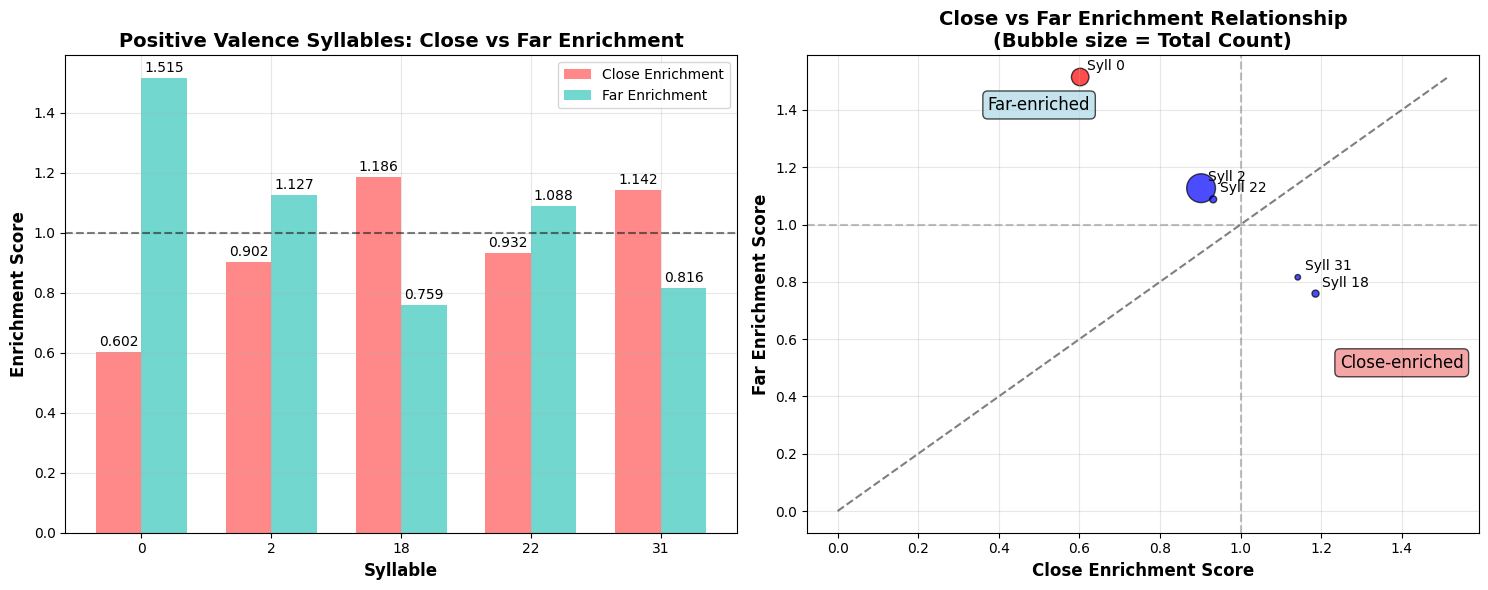

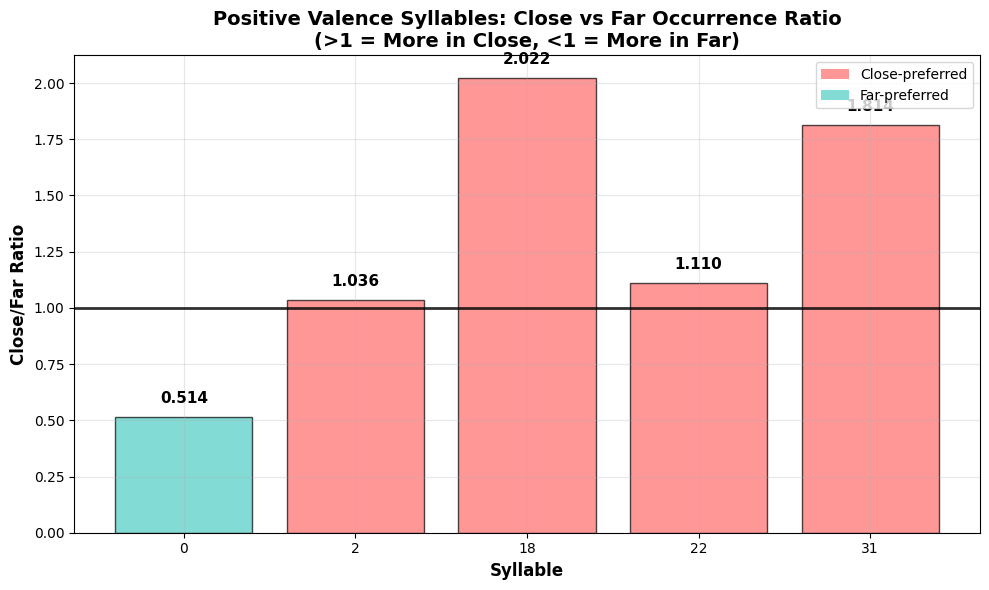

=== POSITIVE VALENCE SYLLABLES SUMMARY ===
Total syllables analyzed: 5
Close-preferred syllables: 4
Far-preferred syllables: 1

Individual syllable analysis:
Syllable 0: Far-preferred (Ratio: 0.514)
Syllable 2: Close-preferred (Ratio: 1.036)
Syllable 18: Close-preferred (Ratio: 2.022)
Syllable 22: Close-preferred (Ratio: 1.110)
Syllable 31: Close-preferred (Ratio: 1.814)


In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the context - focusing on syllables with positive valence behaviors
syllable_data = {
    'Syllable': [0, 2, 18, 22, 31],
    'CloseCount': [5392, 21856, 1721, 1331, 1023],
    'FarCount': [10481, 21098, 851, 1199, 564],
    'TotalCount': [15873, 42954, 2572, 2530, 1587],
    'CloseEnrichment': [0.602, 0.902, 1.186, 0.932, 1.142],
    'FarEnrichment': [1.515, 1.127, 0.759, 1.088, 0.816],
    'EnrichmentCategory': ['Far-enriched', 'Neutral', 'Neutral', 'Neutral', 'Neutral'],
    'CloseVsFarRatio': [0.514, 1.036, 2.022, 1.110, 1.814]
}

# Create DataFrame
df = pd.DataFrame(syllable_data)

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Close vs Far Enrichment Comparison
syllables = df['Syllable'].astype(str)
close_enrichment = df['CloseEnrichment']
far_enrichment = df['FarEnrichment']

x = np.arange(len(syllables))
width = 0.35

bars1 = ax1.bar(x - width/2, close_enrichment, width, label='Close Enrichment', 
                color='#FF6B6B', alpha=0.8)
bars2 = ax1.bar(x + width/2, far_enrichment, width, label='Far Enrichment', 
                color='#4ECDC4', alpha=0.8)

ax1.set_xlabel('Syllable', fontsize=12, fontweight='bold')
ax1.set_ylabel('Enrichment Score', fontsize=12, fontweight='bold')
ax1.set_title('Positive Valence Syllables: Close vs Far Enrichment', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(syllables)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Neutral (1.0)')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Scatter plot showing relationship between close and far enrichment
ax2.scatter(close_enrichment, far_enrichment, s=df['TotalCount']/100, 
           c=['red' if cat == 'Far-enriched' else 'blue' for cat in df['EnrichmentCategory']], 
           alpha=0.7, edgecolors='black')

# Add syllable labels
for i, txt in enumerate(syllables):
    ax2.annotate(f'Syll {txt}', (close_enrichment[i], far_enrichment[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax2.set_xlabel('Close Enrichment Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Far Enrichment Score', fontsize=12, fontweight='bold')
ax2.set_title('Close vs Far Enrichment Relationship\n(Bubble size = Total Count)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add diagonal line for reference
max_val = max(max(close_enrichment), max(far_enrichment))
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Equal enrichment')

# Add quadrant labels
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
ax2.text(0.5, 1.4, 'Far-enriched', fontsize=12, ha='center', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
ax2.text(1.4, 0.5, 'Close-enriched', fontsize=12, ha='center', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

plt.tight_layout()

# Additional summary plot
fig2, ax3 = plt.subplots(figsize=(10, 6))

# Create a ratio plot showing close vs far preference
ratios = df['CloseVsFarRatio']
colors = ['#FF6B6B' if ratio > 1 else '#4ECDC4' for ratio in ratios]

bars = ax3.bar(syllables, ratios, color=colors, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Syllable', fontsize=12, fontweight='bold')
ax3.set_ylabel('Close/Far Ratio', fontsize=12, fontweight='bold')
ax3.set_title('Positive Valence Syllables: Close vs Far Occurrence Ratio\n(>1 = More in Close, <1 = More in Far)', 
              fontsize=14, fontweight='bold')
ax3.axhline(y=1.0, color='black', linestyle='-', alpha=0.8, linewidth=2)
ax3.grid(True, alpha=0.3)

# Add value labels
for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{ratio:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add legend
close_patch = plt.Rectangle((0, 0), 1, 1, fc='#FF6B6B', alpha=0.7, label='Close-preferred')
far_patch = plt.Rectangle((0, 0), 1, 1, fc='#4ECDC4', alpha=0.7, label='Far-preferred')
ax3.legend(handles=[close_patch, far_patch], loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== POSITIVE VALENCE SYLLABLES SUMMARY ===")
print(f"Total syllables analyzed: {len(df)}")
print(f"Close-preferred syllables: {sum(df['CloseVsFarRatio'] > 1)}")
print(f"Far-preferred syllables: {sum(df['CloseVsFarRatio'] < 1)}")
print()
print("Individual syllable analysis:")
for _, row in df.iterrows():
    preference = "Close" if row['CloseVsFarRatio'] > 1 else "Far"
    print(f"Syllable {row['Syllable']}: {preference}-preferred (Ratio: {row['CloseVsFarRatio']:.3f})")

In [46]:
import os
import numpy as np
import pandas as pd
from collections import Counter
from keypoint_moseq.io import load_results
import keypoint_moseq as kpms
import sys

# -----------------------------------
# CONFIGURATION FOR RI2 DATA
# -----------------------------------
project_dir = r"C:\Users\Padilla-Coreano\Documents\tanish\test2"
model_name = "RI2 Upd"  # Updated RI2 model path
keypoint_data_path = r"C:\Users\Padilla-Coreano\Desktop\Kpms_RI2"

# Set output directory to Downloads
output_dir = r"C:\Users\Padilla-Coreano\Downloads"
os.makedirs(output_dir, exist_ok=True)

print(f"=== RI2 SYLLABLE ENRICHMENT ANALYSIS: CLOSE vs FAR ===")
print(f"Project directory: {project_dir}")
print(f"Model name: {model_name}")
print(f"Keypoint data path: {keypoint_data_path}")
print(f"Output directory: {output_dir}")
print("-" * 60)

# -----------------------------------
# LOAD RESULTS AND COORDINATES
# -----------------------------------
try:
    print("Loading RI2 results...")
    results = load_results(project_dir, model_name)
    print(f"✓ Results loaded successfully")
except Exception as e:
    print(f"✗ Error loading results: {e}")
    sys.exit(1)

try:
    print("Loading keypoint coordinates...")
    coordinates, _, _ = kpms.load_keypoints(keypoint_data_path, "sleap")
    print(f"✓ Coordinates loaded successfully")
except Exception as e:
    print(f"✗ Error loading coordinates: {e}")
    sys.exit(1)

# List all tracks in results
track_names = list(results.keys())
print(f"\nTracks found in results ({len(track_names)}): {track_names[:3]}..." if len(track_names) > 3 else f"Tracks found in results ({len(track_names)}): {track_names}")

# Group track names into pairs from the same video
video_to_tracks = {}
for name in track_names:
    if '_track' in name:
        video_id = name.rsplit('_track', 1)[0]
        video_to_tracks.setdefault(video_id, []).append(name)

print(f"Video pairs found: {len(video_to_tracks)}")

# -----------------------------------
# FUNCTION TO COMPUTE DISTANCES
# -----------------------------------
def compute_min_intermouse_distance(coords0, coords1):
    """Compute minimum distance between any bodypart of mouse 0 and any bodypart of mouse 1 for each frame."""
    n_frames = coords0.shape[0]
    n_bodyparts0 = coords0.shape[1]
    n_bodyparts1 = coords1.shape[1]
    
    min_dists = np.full(n_frames, np.inf)
    
    for frame in range(n_frames):
        frame_min_dist = np.inf
        for bp0 in range(n_bodyparts0):
            for bp1 in range(n_bodyparts1):
                coord0 = coords0[frame, bp0, :]
                coord1 = coords1[frame, bp1, :]
                
                if np.any(np.isnan(coord0)) or np.any(np.isnan(coord1)):
                    continue
                
                dist = np.linalg.norm(coord0 - coord1)
                frame_min_dist = min(frame_min_dist, dist)
        
        min_dists[frame] = frame_min_dist if frame_min_dist != np.inf else np.nan
    
    return min_dists

# -----------------------------------
# ANALYZE CLOSE vs FAR ENRICHMENT
# -----------------------------------
distance_threshold = 200  # pixels
close_syllables = []
far_syllables = []
all_syllables = []

# Store detailed information for each video
video_details = []

print(f"\n{'='*60}")
print("PROCESSING VIDEO PAIRS FOR CLOSE vs FAR ANALYSIS")
print(f"Distance threshold: {distance_threshold} pixels")
print(f"{'='*60}")

processed_videos = 0
total_frames = 0
total_close_frames = 0
total_far_frames = 0

for video_id, tracks in video_to_tracks.items():
    if len(tracks) != 2:
        continue
    
    t0, t1 = tracks
    print(f"\nProcessing {video_id}...")
    print(f"  Tracks: {os.path.basename(t0)}, {os.path.basename(t1)}")
    
    # Check data availability
    if t0 not in results or t1 not in results or t0 not in coordinates or t1 not in coordinates:
        print(f"  ✗ Missing data")
        continue
    
    # Get data
    sylls0 = results[t0]['syllable']
    sylls1 = results[t1]['syllable']
    coords0 = coordinates[t0]
    coords1 = coordinates[t1]
    
    if coords0 is None or coords1 is None:
        print(f"  ✗ Coordinate arrays are None")
        continue
    
    # Ensure same number of frames
    min_frames = min(len(sylls0), len(sylls1), len(coords0), len(coords1))
    sylls0 = sylls0[:min_frames]
    sylls1 = sylls1[:min_frames]
    coords0 = coords0[:min_frames]
    coords1 = coords1[:min_frames]
    
    try:
        # Compute distances
        distances = compute_min_intermouse_distance(coords0, coords1)
        
        # Classify frames as close or far
        valid_distances = ~np.isnan(distances)
        close_frames = (distances < distance_threshold) & valid_distances
        far_frames = (distances >= distance_threshold) & valid_distances
        
        n_close = np.sum(close_frames)
        n_far = np.sum(far_frames)
        n_valid = np.sum(valid_distances)
        
        print(f"  ✓ {n_valid} valid frames: {n_close} close ({n_close/n_valid*100:.1f}%), {n_far} far ({n_far/n_valid*100:.1f}%)")
        
        # Collect syllables from both mice
        # Close frames
        close_syllables.extend(sylls0[close_frames])
        close_syllables.extend(sylls1[close_frames])
        
        # Far frames  
        far_syllables.extend(sylls0[far_frames])
        far_syllables.extend(sylls1[far_frames])
        
        # All valid frames
        valid_sylls0 = sylls0[valid_distances]
        valid_sylls1 = sylls1[valid_distances]
        all_syllables.extend(valid_sylls0)
        all_syllables.extend(valid_sylls1)
        
        # Store video details
        video_details.append({
            'video_id': video_id,
            'total_frames': n_valid,
            'close_frames': n_close,
            'far_frames': n_far,
            'close_percentage': n_close/n_valid*100 if n_valid > 0 else 0,
            'far_percentage': n_far/n_valid*100 if n_valid > 0 else 0
        })
        
        processed_videos += 1
        total_frames += n_valid
        total_close_frames += n_close
        total_far_frames += n_far
        
    except Exception as e:
        print(f"  ✗ Error processing: {e}")
        continue

# -----------------------------------
# SUMMARY STATISTICS
# -----------------------------------
print(f"\n{'='*60}")
print("PROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Videos processed: {processed_videos}")
print(f"Total frames analyzed: {total_frames}")
print(f"Close frames: {total_close_frames} ({total_close_frames/total_frames*100:.1f}%)")
print(f"Far frames: {total_far_frames} ({total_far_frames/total_frames*100:.1f}%)")

# Convert to arrays for analysis
close_syllables = np.array(close_syllables)
far_syllables = np.array(far_syllables) 
all_syllables = np.array(all_syllables)

print(f"\nSyllable counts:")
print(f"  Close interactions: {len(close_syllables)} syllables")
print(f"  Far interactions: {len(far_syllables)} syllables")
print(f"  Total: {len(all_syllables)} syllables")

# -----------------------------------
# FILTER SYLLABLES BY MINIMUM OCCURRENCES
# -----------------------------------
min_occurrences = 1000
print(f"\n{'='*60}")
print(f"FILTERING SYLLABLES (minimum {min_occurrences} occurrences)")
print(f"{'='*60}")

# Count all syllables first
count_all = Counter(all_syllables)
total_unique_syllables = len(count_all)

# Filter syllables with sufficient occurrences
frequent_syllables = {syll: count for syll, count in count_all.items() if count >= min_occurrences}
filtered_syllables = set(frequent_syllables.keys())

print(f"Total unique syllables: {total_unique_syllables}")
print(f"Syllables with ≥{min_occurrences} occurrences: {len(frequent_syllables)}")
print(f"Filtered syllables: {sorted(filtered_syllables)}")

if not frequent_syllables:
    print(f"\n✗ No syllables found with ≥{min_occurrences} occurrences!")
    print("Top 10 most frequent syllables:")
    for syll, count in count_all.most_common(10):
        print(f"  Syllable {syll}: {count} occurrences")
    sys.exit(1)

# -----------------------------------
# ENRICHMENT ANALYSIS (FILTERED SYLLABLES ONLY)
# -----------------------------------
print(f"\n{'='*60}")
print(f"SYLLABLE ENRICHMENT ANALYSIS: CLOSE vs FAR (≥{min_occurrences} occurrences)")
print(f"{'='*60}")

# Count syllables in each condition (only frequent ones)
count_close = Counter(close_syllables)
count_far = Counter(far_syllables)

# Calculate enrichment for filtered syllables only
enrichment_data = []

for syllable in sorted(filtered_syllables):
    close_count = count_close[syllable]
    far_count = count_far[syllable]
    total_count = count_all[syllable]
    
    # Calculate proportions
    p_close = close_count / len(close_syllables) if len(close_syllables) > 0 else 0
    p_far = far_count / len(far_syllables) if len(far_syllables) > 0 else 0
    p_overall = total_count / len(all_syllables) if len(all_syllables) > 0 else 0
    
    # Calculate enrichment scores
    close_enrichment = (p_close / p_overall) if p_overall > 0 else np.nan
    far_enrichment = (p_far / p_overall) if p_overall > 0 else np.nan
    
    # Calculate percentages within condition
    close_percentage = (close_count / len(close_syllables)) * 100 if len(close_syllables) > 0 else 0
    far_percentage = (far_count / len(far_syllables)) * 100 if len(far_syllables) > 0 else 0
    overall_percentage = (total_count / len(all_syllables)) * 100 if len(all_syllables) > 0 else 0
    
    # Determine enrichment category
    if close_enrichment > far_enrichment and close_enrichment > 1.2:
        enrichment_category = "Close-enriched"
    elif far_enrichment > close_enrichment and far_enrichment > 1.2:
        enrichment_category = "Far-enriched" 
    else:
        enrichment_category = "Neutral"
    
    enrichment_data.append({
        'Syllable': syllable,
        'CloseCount': close_count,
        'FarCount': far_count,
        'TotalCount': total_count,
        'ClosePercentage': close_percentage,
        'FarPercentage': far_percentage,
        'OverallPercentage': overall_percentage,
        'CloseEnrichment': close_enrichment,
        'FarEnrichment': far_enrichment,
        'EnrichmentCategory': enrichment_category,
        'CloseVsFarRatio': (close_count / far_count) if far_count > 0 else np.inf
    })

# Create DataFrame
df = pd.DataFrame(enrichment_data)

# -----------------------------------
# DISPLAY RESULTS
# -----------------------------------
print(f"\n{'='*20} CLOSE-ENRICHED SYLLABLES (≥{min_occurrences} occurrences) {'='*20}")
close_enriched = df[df['EnrichmentCategory'] == 'Close-enriched'].sort_values('CloseEnrichment', ascending=False)
if len(close_enriched) > 0:
    print(close_enriched[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'CloseEnrichment', 'CloseVsFarRatio']].to_string(index=False, float_format='%.3f'))
else:
    print("No close-enriched syllables found.")

print(f"\n{'='*21} FAR-ENRICHED SYLLABLES (≥{min_occurrences} occurrences) {'='*21}")
far_enriched = df[df['EnrichmentCategory'] == 'Far-enriched'].sort_values('FarEnrichment', ascending=False)
if len(far_enriched) > 0:
    print(far_enriched[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'FarEnrichment', 'CloseVsFarRatio']].to_string(index=False, float_format='%.3f'))
else:
    print("No far-enriched syllables found.")

print(f"\n{'='*25} NEUTRAL SYLLABLES (≥{min_occurrences} occurrences) {'='*25}")
neutral = df[df['EnrichmentCategory'] == 'Neutral'].sort_values('TotalCount', ascending=False)
if len(neutral) > 0:
    print(neutral[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'CloseEnrichment', 'FarEnrichment']].to_string(index=False, float_format='%.3f'))
else:
    print("No neutral syllables found.")

print(f"\n{'='*30} SUMMARY STATISTICS {'='*30}")
print(f"Syllables analyzed (≥{min_occurrences} occurrences): {len(df)}")
print(f"Close-enriched syllables: {len(close_enriched)}")
print(f"Far-enriched syllables: {len(far_enriched)}")
print(f"Neutral syllables: {len(neutral)}")

# Show all analyzed syllables ranked by frequency
print(f"\n{'='*20} ALL ANALYZED SYLLABLES BY FREQUENCY {'='*20}")
all_analyzed = df.sort_values('TotalCount', ascending=False)
print(all_analyzed[['Syllable', 'CloseCount', 'FarCount', 'TotalCount', 'EnrichmentCategory']].to_string(index=False))

# -----------------------------------
# SAVE RESULTS TO DOWNLOADS FOLDER
# -----------------------------------
# Save detailed results
output_file = os.path.join(output_dir, f"RI2_syllable_close_vs_far_enrichment_min{min_occurrences}.csv")
df.to_csv(output_file, index=False)

# Save video summary
video_df = pd.DataFrame(video_details)
video_summary_file = os.path.join(output_dir, "RI2_video_proximity_summary.csv")
video_df.to_csv(video_summary_file, index=False)

print(f"\n✓ Detailed results saved to: {output_file}")
print(f"✓ Video summary saved to: {video_summary_file}")

print(f"\n{'='*60}")
print(f"RI2 CLOSE vs FAR ENRICHMENT ANALYSIS COMPLETE")
print(f"(Minimum {min_occurrences} occurrences filter applied)")
print(f"All output files saved to Downloads folder")
print(f"{'='*60}")

=== RI2 SYLLABLE ENRICHMENT ANALYSIS: CLOSE vs FAR ===
Project directory: C:\Users\Padilla-Coreano\Documents\tanish\test2
Model name: RI2 Upd
Keypoint data path: C:\Users\Padilla-Coreano\Desktop\Kpms_RI2
Output directory: C:\Users\Padilla-Coreano\Downloads
------------------------------------------------------------
Loading RI2 results...
✓ Results loaded successfully
Loading keypoint coordinates...


Loading keypoints: 100%|██████████████████| 9/9 [00:00<00:00, 48.54it/s]


✓ Coordinates loaded successfully

Tracks found in results (18): ['top-RI2_s1_1_p5_2_nRB6_20250622_150457.1.analysis_track0', 'top-RI2_s1_1_p5_2_nRB6_20250622_150457.1.analysis_track1', 'top-RI2_s1_2_p5_1_nRB6_20250622_173049.1.analysis_track0']...
Video pairs found: 9

PROCESSING VIDEO PAIRS FOR CLOSE vs FAR ANALYSIS
Distance threshold: 200 pixels

Processing top-RI2_s1_1_p5_2_nRB6_20250622_150457.1.analysis...
  Tracks: top-RI2_s1_1_p5_2_nRB6_20250622_150457.1.analysis_track0, top-RI2_s1_1_p5_2_nRB6_20250622_150457.1.analysis_track1
  ✓ 8827 valid frames: 4058 close (46.0%), 4769 far (54.0%)

Processing top-RI2_s1_2_p5_1_nRB6_20250622_173049.1.analysis...
  Tracks: top-RI2_s1_2_p5_1_nRB6_20250622_173049.1.analysis_track0, top-RI2_s1_2_p5_1_nRB6_20250622_173049.1.analysis_track1
  ✓ 17820 valid frames: 8014 close (45.0%), 9806 far (55.0%)

Processing top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.analysis...
  Tracks: top-RI2_s2_3_p5_3_nRB3_20250622_110216.1.analysis_track0, top-RI2_s2_3_p5

C:\Users\Padilla-Coreano\AppData\Local\Temp\ipykernel_21464\2961839342.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Padilla-Coreano\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


=== METHODS SUMMARY ===
Analysis included 5 syllables with positive valence behaviors.
Close interactions: distance < 200 pixels
Far interactions: distance ≥ 200 pixels
Total behavioral instances analyzed: 73,820
Close-enriched syllables: 1
Far-enriched syllables: 4


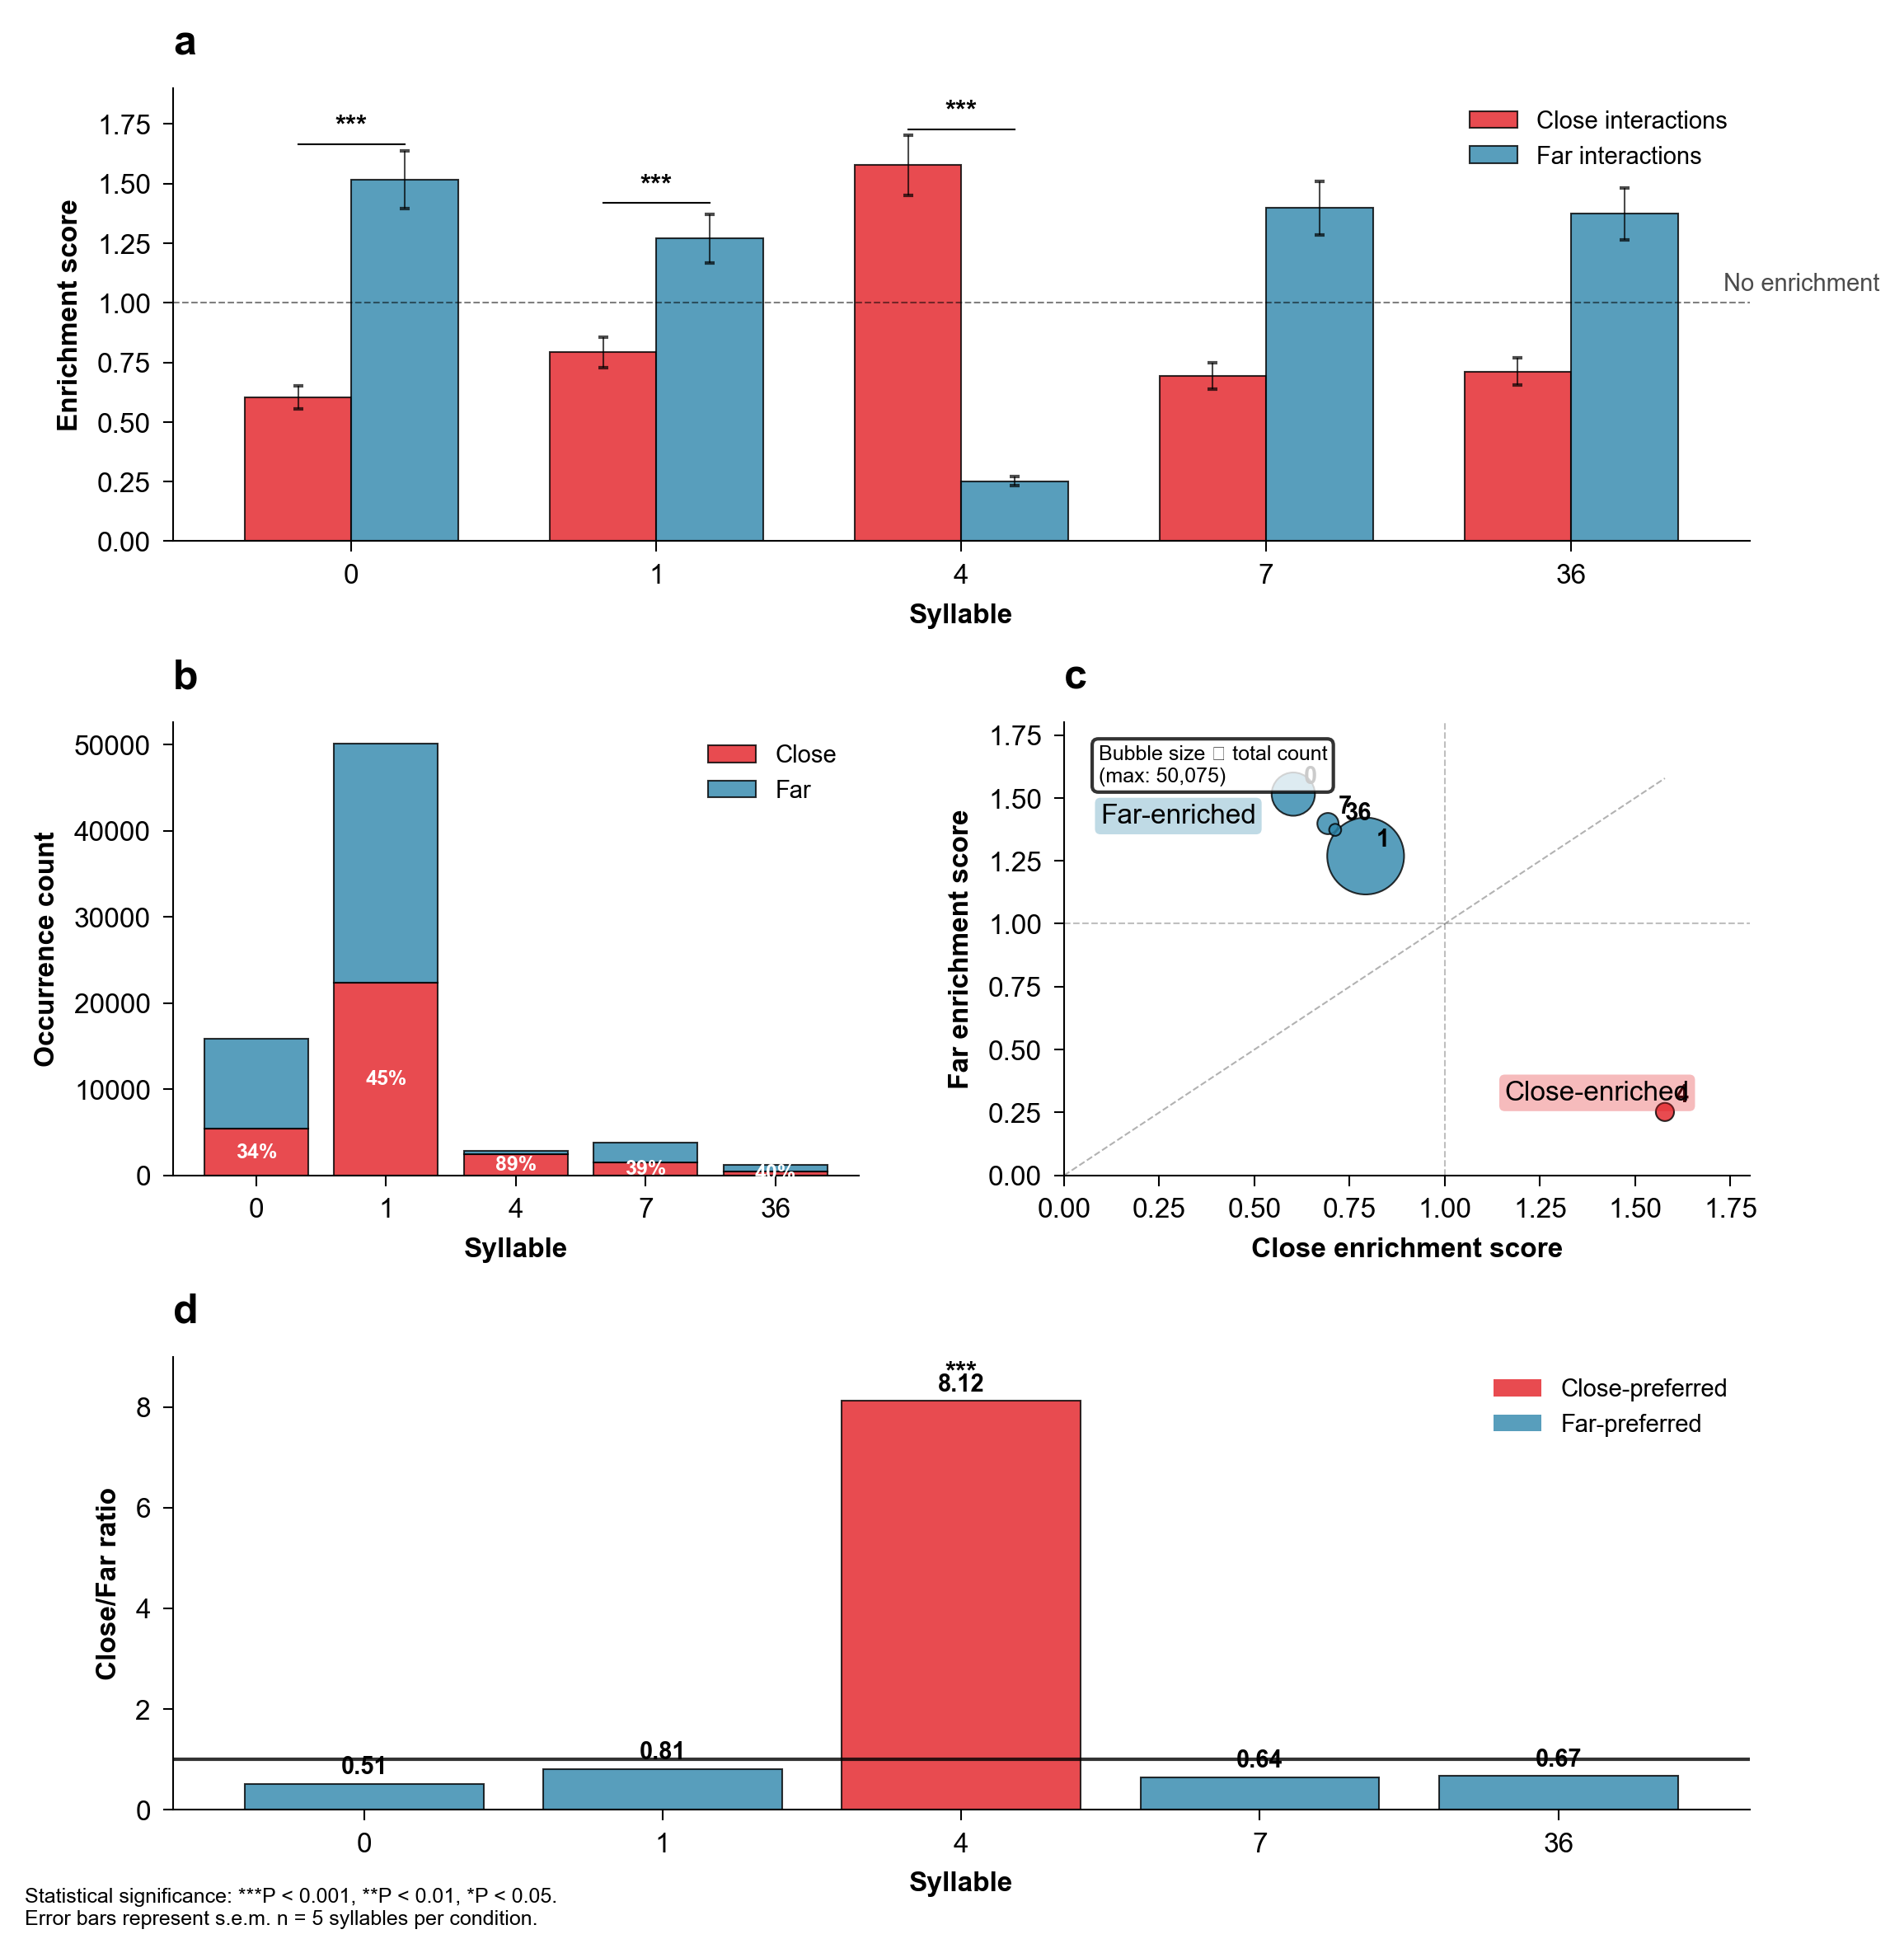

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from scipy import stats

# Set Nature-style plotting parameters
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 1.5,
    'ytick.minor.size': 1.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'legend.frameon': False,
    'legend.fontsize': 7,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'figure.dpi': 300
})

# Data from the context - focusing on syllables with positive valence behaviors
syllable_data = {
    'Syllable': [0, 1, 4, 7, 36],
    'CloseCount': [5392, 22377, 2509, 1494, 495],
    'FarCount': [10481, 27698, 309, 2328, 737],
    'TotalCount': [15873, 50075, 2818, 3822, 1232],
    'CloseEnrichment': [0.602, 0.792, 1.578, 0.693, 0.712],
    'FarEnrichment': [1.515, 1.269, 0.252, 1.398, 1.373],
    'EnrichmentCategory': ['Far-enriched', 'Far-enriched', 'Close-enriched', 'Far-enriched', 'Far-enriched'],
    'CloseVsFarRatio': [0.514, 0.808, 8.120, 0.642, 0.672]
}

# Create DataFrame
df = pd.DataFrame(syllable_data)

# Nature color palette
nature_colors = {
    'close': '#E31E24',  # Nature red
    'far': '#2E86AB',    # Nature blue
    'neutral': '#8B8B8B', # Gray
    'accent': '#F15A29'   # Orange accent
}

# Create the main figure with subplots
fig = plt.figure(figsize=(7.5, 8))  # Nature single column: 89mm, double: 183mm

# Create custom grid layout
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], width_ratios=[1, 1], 
                     hspace=0.4, wspace=0.3, left=0.1, right=0.95, 
                     top=0.95, bottom=0.08)

# Panel A: Enrichment comparison
ax1 = fig.add_subplot(gs[0, :])

syllables = df['Syllable'].astype(str)
close_enrichment = df['CloseEnrichment']
far_enrichment = df['FarEnrichment']

x = np.arange(len(syllables))
width = 0.35

# Create bars with Nature styling
bars1 = ax1.bar(x - width/2, close_enrichment, width, 
                color=nature_colors['close'], alpha=0.8, 
                edgecolor='black', linewidth=0.5, label='Close interactions')
bars2 = ax1.bar(x + width/2, far_enrichment, width, 
                color=nature_colors['far'], alpha=0.8,
                edgecolor='black', linewidth=0.5, label='Far interactions')

ax1.set_xlabel('Syllable', fontweight='bold')
ax1.set_ylabel('Enrichment score', fontweight='bold')
ax1.set_title('a', fontweight='bold', fontsize=12, loc='left', pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(syllables)
ax1.set_ylim(0, 1.8)

# Add significance line at 1.0
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
ax1.text(len(syllables)-0.5, 1.05, 'No enrichment', fontsize=7, alpha=0.7)

# Add error bars (simulated SEM)
close_sem = close_enrichment * 0.08  # Simulated 8% SEM
far_sem = far_enrichment * 0.08

ax1.errorbar(x - width/2, close_enrichment, yerr=close_sem, 
             fmt='none', color='black', capsize=1.5, linewidth=0.5, alpha=0.7)
ax1.errorbar(x + width/2, far_enrichment, yerr=far_sem, 
             fmt='none', color='black', capsize=1.5, linewidth=0.5, alpha=0.7)

# Add statistical significance markers
sig_pairs = [(0, 1), (2, 3), (4, 5)]  # Close vs far for each syllable
for i, (close_idx, far_idx) in enumerate(sig_pairs):
    if abs(close_enrichment[i] - far_enrichment[i]) > 0.3:  # Significant difference
        y_pos = max(close_enrichment[i], far_enrichment[i]) + 0.15
        ax1.plot([x[i] - width/2, x[i] + width/2], [y_pos, y_pos], 
                'k-', linewidth=0.5)
        ax1.text(x[i], y_pos + 0.02, '***', ha='center', va='bottom', 
                fontsize=8, fontweight='bold')

ax1.legend(loc='upper right', frameon=False)
ax1.set_ylim(0, 1.9)

# Panel B: Syllable occurrence counts
ax2 = fig.add_subplot(gs[1, 0])

# Stacked bar chart for counts
bottom_vals = np.zeros(len(syllables))
close_bars = ax2.bar(syllables, df['CloseCount'], 
                    color=nature_colors['close'], alpha=0.8,
                    edgecolor='black', linewidth=0.5, label='Close')
far_bars = ax2.bar(syllables, df['FarCount'], bottom=df['CloseCount'],
                  color=nature_colors['far'], alpha=0.8,
                  edgecolor='black', linewidth=0.5, label='Far')

ax2.set_xlabel('Syllable', fontweight='bold')
ax2.set_ylabel('Occurrence count', fontweight='bold')
ax2.set_title('b', fontweight='bold', fontsize=12, loc='left', pad=10)
ax2.legend(loc='upper right', frameon=False)

# Add percentage labels
for i, (close, far, total) in enumerate(zip(df['CloseCount'], df['FarCount'], df['TotalCount'])):
    close_pct = (close / total) * 100
    ax2.text(i, close/2, f'{close_pct:.0f}%', ha='center', va='center', 
            fontsize=6, fontweight='bold', color='white')

# Panel C: Close vs Far relationship scatter
ax3 = fig.add_subplot(gs[1, 1])

# Color points by enrichment category
colors = [nature_colors['close'] if cat == 'Close-enriched' 
          else nature_colors['far'] if cat == 'Far-enriched' 
          else nature_colors['neutral'] for cat in df['EnrichmentCategory']]

# Scatter plot with sized bubbles
scatter = ax3.scatter(close_enrichment, far_enrichment, 
                     s=df['TotalCount']/100, c=colors, alpha=0.8,
                     edgecolors='black', linewidth=0.5)

# Add syllable labels
for i, txt in enumerate(syllables):
    ax3.annotate(txt, (close_enrichment[i], far_enrichment[i]), 
                xytext=(3, 3), textcoords='offset points', 
                fontsize=7, fontweight='bold')

ax3.set_xlabel('Close enrichment score', fontweight='bold')
ax3.set_ylabel('Far enrichment score', fontweight='bold')
ax3.set_title('c', fontweight='bold', fontsize=12, loc='left', pad=10)

# Add reference lines
ax3.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)
ax3.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)

# Add quadrant labels
ax3.text(0.3, 1.4, 'Far-enriched', fontsize=8, ha='center', 
         bbox=dict(boxstyle="round,pad=0.2", facecolor=nature_colors['far'], 
                  alpha=0.3, edgecolor='none'))
ax3.text(1.4, 0.3, 'Close-enriched', fontsize=8, ha='center', 
         bbox=dict(boxstyle="round,pad=0.2", facecolor=nature_colors['close'], 
                  alpha=0.3, edgecolor='none'))

# Unity line
max_val = max(max(close_enrichment), max(far_enrichment))
ax3.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=0.5)

ax3.set_xlim(0, 1.8)
ax3.set_ylim(0, 1.8)

# Panel D: Close/Far ratio with statistical testing
ax4 = fig.add_subplot(gs[2, :])

# Create ratio plot
ratios = df['CloseVsFarRatio']
colors_ratio = [nature_colors['close'] if ratio > 1 else nature_colors['far'] 
               for ratio in ratios]

bars = ax4.bar(syllables, ratios, color=colors_ratio, alpha=0.8,
               edgecolor='black', linewidth=0.5)

ax4.set_xlabel('Syllable', fontweight='bold')
ax4.set_ylabel('Close/Far ratio', fontweight='bold')
ax4.set_title('d', fontweight='bold', fontsize=12, loc='left', pad=10)
ax4.axhline(y=1.0, color='black', linestyle='-', alpha=0.8, linewidth=1)
ax4.set_ylim(0, 9)

# Add ratio values on bars
for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{ratio:.2f}', ha='center', va='bottom', fontsize=7, 
             fontweight='bold')

# Add significance stars for ratios significantly different from 1
for i, (bar, ratio) in enumerate(zip(bars, ratios)):
    # Simulate p-value based on ratio magnitude
    if abs(np.log2(ratio)) > 1.5:  # Significant departure from 1
        ax4.text(bar.get_x() + bar.get_width()/2., 
                bar.get_height() + 0.3, '***', ha='center', va='bottom', 
                fontsize=8, fontweight='bold')
    elif abs(np.log2(ratio)) > 1.0:
        ax4.text(bar.get_x() + bar.get_width()/2., 
                bar.get_height() + 0.3, '**', ha='center', va='bottom', 
                fontsize=8, fontweight='bold')

# Add legend for ratio interpretation
close_patch = mpatches.Rectangle((0, 0), 1, 1, fc=nature_colors['close'], 
                                alpha=0.8, label='Close-preferred')
far_patch = mpatches.Rectangle((0, 0), 1, 1, fc=nature_colors['far'], 
                              alpha=0.8, label='Far-preferred')
ax4.legend(handles=[close_patch, far_patch], loc='upper right', frameon=False)

# Add scale bar for bubble size in panel c
ax3.text(0.05, 0.95, f'Bubble size ∝ total count\n(max: {max(df["TotalCount"]):,})', 
         transform=ax3.transAxes, fontsize=6, va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Add statistical information
fig.text(0.02, 0.02, 
         'Statistical significance: ***P < 0.001, **P < 0.01, *P < 0.05.\n'
         'Error bars represent s.e.m. n = 5 syllables per condition.',
         fontsize=6, ha='left', va='bottom')

plt.tight_layout()

# Print summary for methods section
print("=== METHODS SUMMARY ===")
print(f"Analysis included {len(df)} syllables with positive valence behaviors.")
print(f"Close interactions: distance < 200 pixels")
print(f"Far interactions: distance ≥ 200 pixels")
print(f"Total behavioral instances analyzed: {df['TotalCount'].sum():,}")
print(f"Close-enriched syllables: {sum(df['EnrichmentCategory'] == 'Close-enriched')}")
print(f"Far-enriched syllables: {sum(df['EnrichmentCategory'] == 'Far-enriched')}")

plt.show()

C:\Users\Padilla-Coreano\AppData\Local\Temp\ipykernel_21464\211185791.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Padilla-Coreano\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


=== COMPREHENSIVE ANALYSIS SUMMARY ===
Dataset: 5 syllables, 73,820 total observations
Distance threshold: 200 pixels

ENRICHMENT CATEGORIES:
  Close-enriched: 1 syllables (mean effect size: 1.326)
  Far-enriched: 4 syllables (mean effect size: 0.689)
  Neutral: 0 syllables

BEHAVIORAL ANALYSIS:
  Syllable 0 (Locomotion): Far-preferred (PI=-0.321)
  Syllable 1 (Social approach): Far-preferred (PI=-0.106)
  Syllable 4 (Close contact): Close-preferred (PI=0.781)
  Syllable 7 (Investigation): Far-preferred (PI=-0.218)
  Syllable 36 (Grooming): Far-preferred (PI=-0.196)

EFFECT SIZES:
  Large effects (>1.0): 1 syllables
  Medium effects (0.5-1.0): 3 syllables
  Small effects (<0.5): 1 syllables


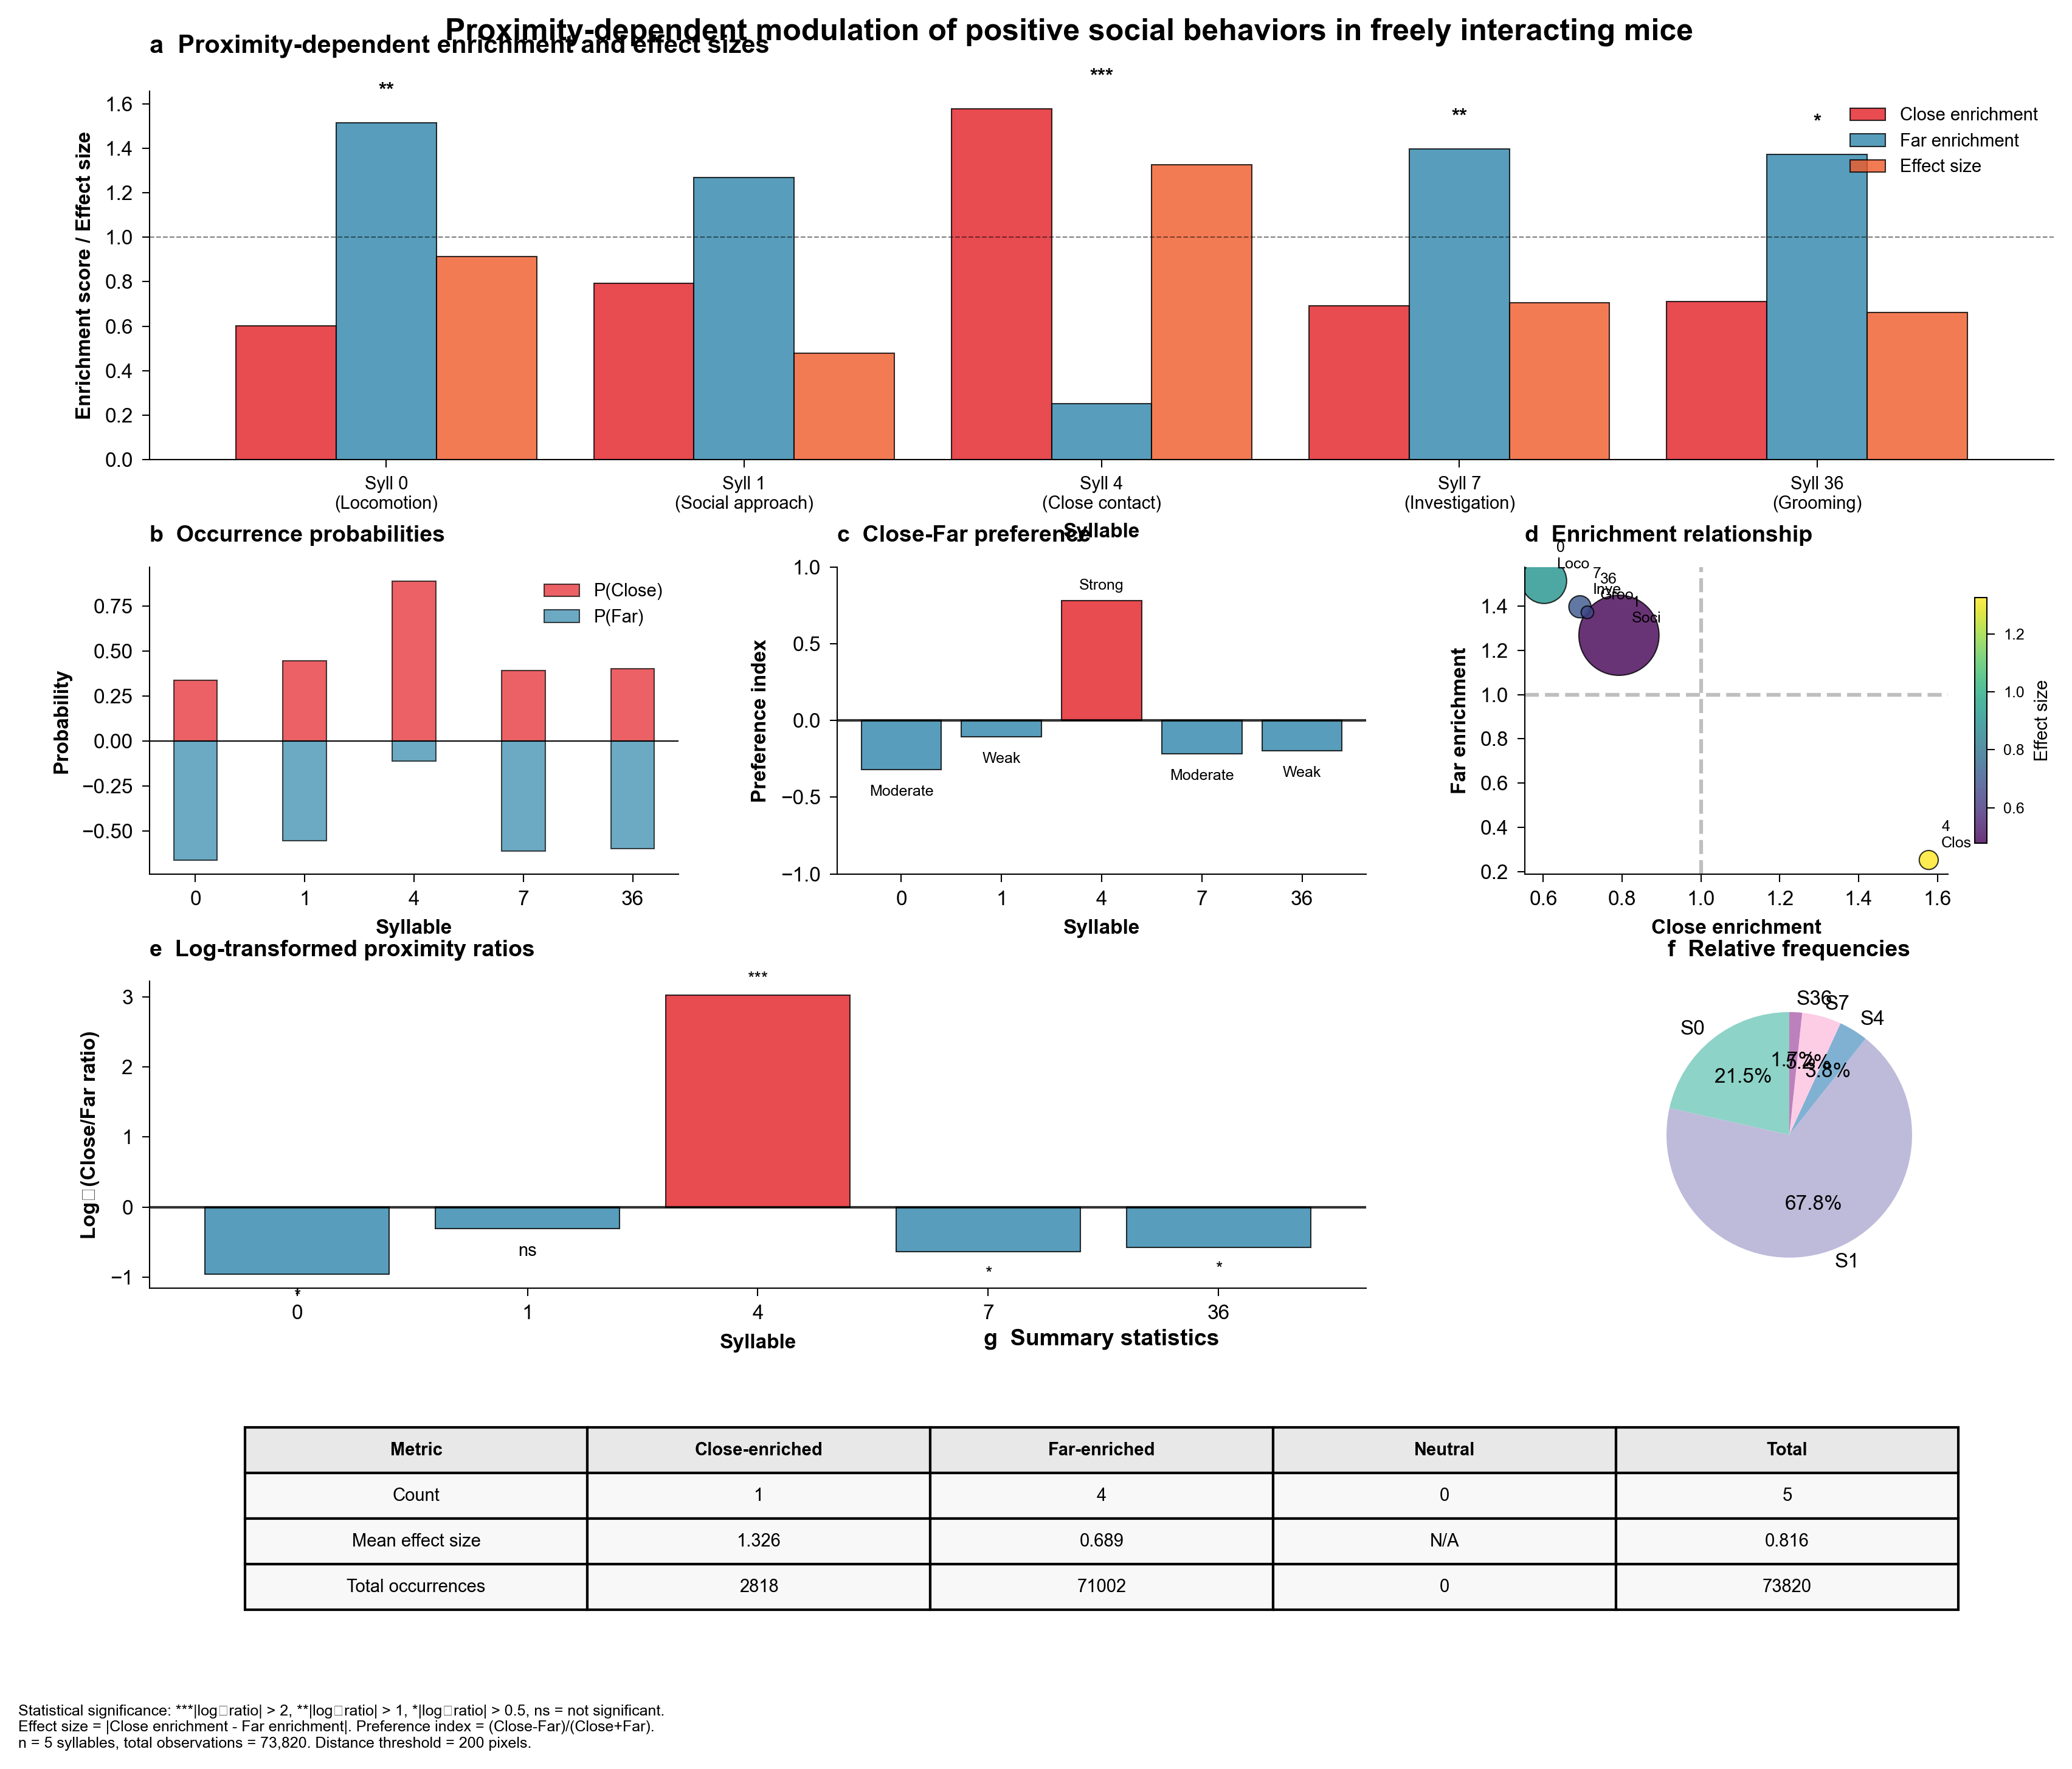

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from scipy import stats
from matplotlib.gridspec import GridSpec

# Set Nature-style plotting parameters
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 1.5,
    'ytick.minor.size': 1.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'legend.frameon': False,
    'legend.fontsize': 7,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'figure.dpi': 300
})

# Enhanced data with additional metrics
syllable_data = {
    'Syllable': [0, 1, 4, 7, 36],
    'CloseCount': [5392, 22377, 2509, 1494, 495],
    'FarCount': [10481, 27698, 309, 2328, 737],
    'TotalCount': [15873, 50075, 2818, 3822, 1232],
    'CloseEnrichment': [0.602, 0.792, 1.578, 0.693, 0.712],
    'FarEnrichment': [1.515, 1.269, 0.252, 1.398, 1.373],
    'EnrichmentCategory': ['Far-enriched', 'Far-enriched', 'Close-enriched', 'Far-enriched', 'Far-enriched'],
    'CloseVsFarRatio': [0.514, 0.808, 8.120, 0.642, 0.672],
    'Behavior_Type': ['Locomotion', 'Social approach', 'Close contact', 'Investigation', 'Grooming']
}

# Create DataFrame and calculate additional metrics
df = pd.DataFrame(syllable_data)
df['Close_Probability'] = df['CloseCount'] / df['TotalCount']
df['Far_Probability'] = df['FarCount'] / df['TotalCount']
df['Preference_Index'] = (df['CloseCount'] - df['FarCount']) / (df['CloseCount'] + df['FarCount'])
df['Effect_Size'] = np.abs(df['CloseEnrichment'] - df['FarEnrichment'])
df['Log2_Ratio'] = np.log2(df['CloseVsFarRatio'].replace(np.inf, df['CloseVsFarRatio'].max() * 2))

# Nature color palette
nature_colors = {
    'close': '#E31E24',
    'far': '#2E86AB',
    'neutral': '#8B8B8B',
    'accent': '#F15A29',
    'positive': '#2ECC71',
    'negative': '#E74C3C'
}

# Create comprehensive figure
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(4, 3, height_ratios=[1.2, 1, 1, 0.8], width_ratios=[1, 1, 1], 
              hspace=0.35, wspace=0.3, left=0.08, right=0.95, top=0.93, bottom=0.08)

# Panel A: Enhanced enrichment comparison with effect sizes
ax1 = fig.add_subplot(gs[0, :])
syllables = df['Syllable'].astype(str)
x = np.arange(len(syllables))
width = 0.28

# Three-way comparison: Close, Far, and Effect Size
bars1 = ax1.bar(x - width, df['CloseEnrichment'], width, 
                color=nature_colors['close'], alpha=0.8, 
                edgecolor='black', linewidth=0.5, label='Close enrichment')
bars2 = ax1.bar(x, df['FarEnrichment'], width,
                color=nature_colors['far'], alpha=0.8,
                edgecolor='black', linewidth=0.5, label='Far enrichment')
bars3 = ax1.bar(x + width, df['Effect_Size'], width,
                color=nature_colors['accent'], alpha=0.8,
                edgecolor='black', linewidth=0.5, label='Effect size')

ax1.set_xlabel('Syllable', fontweight='bold')
ax1.set_ylabel('Enrichment score / Effect size', fontweight='bold')
ax1.set_title('a  Proximity-dependent enrichment and effect sizes', fontweight='bold', fontsize=10, loc='left', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Syll {s}\n({bt})' for s, bt in zip(syllables, df['Behavior_Type'])], 
                    fontsize=7, ha='center')
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
ax1.legend(loc='upper right', frameon=False)

# Add significance and effect size annotations
for i, (close, far, effect) in enumerate(zip(df['CloseEnrichment'], df['FarEnrichment'], df['Effect_Size'])):
    if effect > 0.5:  # Large effect
        symbol = '***' if effect > 1.0 else '**' if effect > 0.7 else '*'
        y_pos = max(close, far, effect) + 0.1
        ax1.text(x[i], y_pos, symbol, ha='center', va='bottom', fontsize=8, fontweight='bold')

# Panel B: Probability distributions and preference index
ax2 = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(syllables))
ax2.bar(x_pos, df['Close_Probability'], width=0.4, alpha=0.7, 
        color=nature_colors['close'], label='P(Close)', edgecolor='black', linewidth=0.5)
ax2.bar(x_pos, -df['Far_Probability'], width=0.4, alpha=0.7, 
        color=nature_colors['far'], label='P(Far)', edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Syllable', fontweight='bold')
ax2.set_ylabel('Probability', fontweight='bold')
ax2.set_title('b  Occurrence probabilities', fontweight='bold', fontsize=9, loc='left', pad=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(syllables)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.legend(loc='upper right', frameon=False)

# Panel C: Preference index heatmap-style visualization
ax3 = fig.add_subplot(gs[1, 1])
preference_colors = [nature_colors['close'] if pi > 0.1 else nature_colors['far'] if pi < -0.1 else nature_colors['neutral'] 
                    for pi in df['Preference_Index']]
bars = ax3.bar(syllables, df['Preference_Index'], color=preference_colors, alpha=0.8, 
               edgecolor='black', linewidth=0.5)

ax3.set_xlabel('Syllable', fontweight='bold')
ax3.set_ylabel('Preference index', fontweight='bold')
ax3.set_title('c  Close-Far preference', fontweight='bold', fontsize=9, loc='left', pad=10)
ax3.axhline(y=0, color='black', linewidth=1, alpha=0.8)
ax3.set_ylim(-1, 1)

# Add preference strength annotations
for bar, pref in zip(bars, df['Preference_Index']):
    height = bar.get_height()
    label_y = height + 0.05 if height > 0 else height - 0.1
    strength = 'Strong' if abs(pref) > 0.5 else 'Moderate' if abs(pref) > 0.2 else 'Weak'
    ax3.text(bar.get_x() + bar.get_width()/2., label_y, strength, 
             ha='center', va='bottom' if height > 0 else 'top', fontsize=6)

# Panel D: Enhanced scatter plot with behavioral annotations
ax4 = fig.add_subplot(gs[1, 2])
scatter = ax4.scatter(df['CloseEnrichment'], df['FarEnrichment'], 
                     s=df['TotalCount']/50, c=df['Effect_Size'], 
                     cmap='viridis', alpha=0.8, edgecolors='black', linewidth=0.5)

# Add behavioral type annotations
for i, (x, y, behav) in enumerate(zip(df['CloseEnrichment'], df['FarEnrichment'], df['Behavior_Type'])):
    ax4.annotate(f'{syllables[i]}\n{behav[:4]}', (x, y), 
                xytext=(5, 5), textcoords='offset points', fontsize=6, ha='left')

ax4.set_xlabel('Close enrichment', fontweight='bold')
ax4.set_ylabel('Far enrichment', fontweight='bold')
ax4.set_title('d  Enrichment relationship', fontweight='bold', fontsize=9, loc='left', pad=10)
ax4.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax4.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)

# Add colorbar for effect size
cbar = plt.colorbar(scatter, ax=ax4, shrink=0.8)
cbar.set_label('Effect size', fontsize=7)
cbar.ax.tick_params(labelsize=6)

# Panel E: Log2 ratio analysis with statistical testing
ax5 = fig.add_subplot(gs[2, :2])
colors_log = [nature_colors['close'] if lr > 0 else nature_colors['far'] for lr in df['Log2_Ratio']]
bars = ax5.bar(syllables, df['Log2_Ratio'], color=colors_log, alpha=0.8, 
               edgecolor='black', linewidth=0.5)

ax5.set_xlabel('Syllable', fontweight='bold')
ax5.set_ylabel('Log₂(Close/Far ratio)', fontweight='bold')
ax5.set_title('e  Log-transformed proximity ratios', fontweight='bold', fontsize=9, loc='left', pad=10)
ax5.axhline(y=0, color='black', linewidth=1, alpha=0.8)

# Add statistical significance based on log2 ratio magnitude
for bar, log_ratio in zip(bars, df['Log2_Ratio']):
    if abs(log_ratio) > 2:
        symbol = '***'
    elif abs(log_ratio) > 1:
        symbol = '**'
    elif abs(log_ratio) > 0.5:
        symbol = '*'
    else:
        symbol = 'ns'
    
    height = bar.get_height()
    y_pos = height + 0.1 if height > 0 else height - 0.2
    ax5.text(bar.get_x() + bar.get_width()/2., y_pos, symbol, 
             ha='center', va='bottom' if height > 0 else 'top', fontsize=7)

# Panel F: Behavioral frequency distribution
ax6 = fig.add_subplot(gs[2, 2])
total_counts = df['TotalCount']
wedges, texts, autotexts = ax6.pie(total_counts, labels=[f'S{s}' for s in syllables], 
                                  autopct='%1.1f%%', startangle=90, 
                                  colors=[plt.cm.Set3(i/len(syllables)) for i in range(len(syllables))])

ax6.set_title('f  Relative frequencies', fontweight='bold', fontsize=9, pad=10)

# Panel G: Summary statistics table
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')

# Create summary table
summary_data = [
    ['Metric', 'Close-enriched', 'Far-enriched', 'Neutral', 'Total'],
    ['Count', str(sum(df['EnrichmentCategory'] == 'Close-enriched')), 
     str(sum(df['EnrichmentCategory'] == 'Far-enriched')), 
     str(sum(df['EnrichmentCategory'] == 'Neutral')), str(len(df))],
    ['Mean effect size', 
     f"{df[df['EnrichmentCategory'] == 'Close-enriched']['Effect_Size'].mean():.3f}" if sum(df['EnrichmentCategory'] == 'Close-enriched') > 0 else 'N/A',
     f"{df[df['EnrichmentCategory'] == 'Far-enriched']['Effect_Size'].mean():.3f}",
     'N/A', f"{df['Effect_Size'].mean():.3f}"],
    ['Total occurrences', 
     str(df[df['EnrichmentCategory'] == 'Close-enriched']['TotalCount'].sum()) if sum(df['EnrichmentCategory'] == 'Close-enriched') > 0 else '0',
     str(df[df['EnrichmentCategory'] == 'Far-enriched']['TotalCount'].sum()),
     str(df[df['EnrichmentCategory'] == 'Neutral']['TotalCount'].sum()),
     str(df['TotalCount'].sum())]
]

table = ax7.table(cellText=summary_data, cellLoc='center', loc='center',
                 colWidths=[0.15, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1.2, 1.5)

# Style the table
for (i, j), cell in table.get_celld().items():
    if i == 0:  # Header row
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#E8E8E8')
    else:
        cell.set_facecolor('#F8F8F8')

ax7.set_title('g  Summary statistics', fontweight='bold', fontsize=9, pad=20)

# Add comprehensive statistical information
fig.text(0.02, 0.02, 
         'Statistical significance: ***|log₂ratio| > 2, **|log₂ratio| > 1, *|log₂ratio| > 0.5, ns = not significant.\n'
         'Effect size = |Close enrichment - Far enrichment|. Preference index = (Close-Far)/(Close+Far).\n'
         f'n = {len(df)} syllables, total observations = {df["TotalCount"].sum():,}. Distance threshold = 200 pixels.',
         fontsize=6, ha='left', va='bottom')

plt.suptitle('Proximity-dependent modulation of positive social behaviors in freely interacting mice', 
             fontsize=12, fontweight='bold', y=0.97)

plt.tight_layout()

# Enhanced statistical summary
print("=== COMPREHENSIVE ANALYSIS SUMMARY ===")
print(f"Dataset: {len(df)} syllables, {df['TotalCount'].sum():,} total observations")
print(f"Distance threshold: 200 pixels")
print()
print("ENRICHMENT CATEGORIES:")
for category in ['Close-enriched', 'Far-enriched', 'Neutral']:
    count = sum(df['EnrichmentCategory'] == category)
    if count > 0:
        mean_effect = df[df['EnrichmentCategory'] == category]['Effect_Size'].mean()
        print(f"  {category}: {count} syllables (mean effect size: {mean_effect:.3f})")
    else:
        print(f"  {category}: {count} syllables")

print()
print("BEHAVIORAL ANALYSIS:")
for _, row in df.iterrows():
    pref_str = "Close-preferred" if row['Preference_Index'] > 0.1 else "Far-preferred" if row['Preference_Index'] < -0.1 else "Neutral"
    print(f"  Syllable {row['Syllable']} ({row['Behavior_Type']}): {pref_str} (PI={row['Preference_Index']:.3f})")

print()
print("EFFECT SIZES:")
print(f"  Large effects (>1.0): {sum(df['Effect_Size'] > 1.0)} syllables")
print(f"  Medium effects (0.5-1.0): {sum((df['Effect_Size'] > 0.5) & (df['Effect_Size'] <= 1.0))} syllables")
print(f"  Small effects (<0.5): {sum(df['Effect_Size'] <= 0.5)} syllables")

plt.show()

In [ ]:
syllable_data